# util

In [ ]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

def auto_piss_extractor(time_series, num_pip=0.2):
    def pd_distance(parameter):
        p1_x, p1_y, p2_x, p2_y, p3_x, p3_y = parameter[0], parameter[1], parameter[2], \
                                             parameter[3], parameter[4], parameter[5]
        b = -1
        a = (p2_y - p3_y) / (p2_x - p3_x)
        c = p2_y - p2_x * a
        return abs(b * p1_y + a * p1_x + c) / np.sqrt(a ** 2 + b ** 2)

    max_no_pip = int(num_pip*len(time_series))
    # Init list of index of time_series with z_norm
    list_index_z = stats.zscore(list(range(len(time_series))))

    piss = []
    pips = [0, (len(time_series) - 1)]
    remain_pos = list(range(1, (len(time_series) - 1)))
    for i in range(max_no_pip - 2):
        biggest_dist = -1
        biggest_dist_pos = -1
        for j in remain_pos:
            p_y = time_series[j]
            p_x = list_index_z[j]
            # Find the adjective point (p2,p3) of p in pips
            p2_x = p2_y = p3_x = p3_y = None
            for g in range(len(pips)):
                end_pos = pips[g]
                if j < end_pos:
                    p2_y, p2_x = time_series[end_pos], list_index_z[end_pos]
                    start_pos = pips[g - 1]
                    p3_y, p3_x = time_series[start_pos], list_index_z[start_pos]
                    break
            # Calculate the distance of p to p2,p3
            distance = pd_distance(parameter=[p_x, p_y, p2_x, p2_y, p3_x, p3_y])
            if distance > biggest_dist:
                biggest_dist, biggest_dist_pos = distance, j
        # Add biggest_dist_pos into pips
        if biggest_dist_pos == -1:
            print("-dist errpr-")

        pips.append(biggest_dist_pos)
        pips.sort()
        # Remove biggest_dist_pos from remain_pos
        remain_pos.remove(biggest_dist_pos)

        # Append new piss
        pos = pips.index(biggest_dist_pos)
        piss.append(np.asarray([pips[pos - 1], pips[pos + 1]]))
        if pos > 1:
            piss.append(np.asarray([pips[pos-2], pips[pos]]))
        if pos < len(pips) - 2:
            piss.append(np.asarray([pips[pos], pips[pos+2]]))
        # print(len(piss))
    return np.asarray(piss)


def auto_ci_extractor(time_series, piss):
    def ci(time_series):
        return (time_series[:-1] - time_series[1:]) ** 2

    ts_ci = ci(time_series)
    list_ci_piss = []
    for j in range(len(piss)):
        ci = np.sqrt(np.sum(ts_ci[piss[j][0]:piss[j][1] - 1]) + 0.001)
        list_ci_piss.append(ci)
    return ts_ci, list_ci_piss


def pcs_extractor(pis, w, len_of_ts):
    if w == 0:
        return pis

    start_pos = pis[0] - w + 1
    start_pos = start_pos if start_pos >= 0 else 0
    end_pos = pis[1] + w
    end_pos = end_pos if end_pos < len_of_ts else len_of_ts

    return np.asarray([start_pos, end_pos])


def ci_extractor(time_series, list_important_point):
    def ci(time_series):
        return (time_series[:-1] - time_series[1:]) ** 2

    ts_ci = ci(time_series)
    list_ci_piss = []
    for j in range(len(list_important_point)-2):
        ci = np.sqrt(np.sum(ts_ci[list_important_point[j]:list_important_point[j+2] - 1]) + 0.001)
        list_ci_piss.append(ci)
    return ts_ci, list_ci_piss


def find_min_dist(pis, pcs, matrix_t1, list_start_pos, list_end_pos, pis_ci, pcs_ci_list):
    sdist = calculate_subdist(matrix_t1, pis, list_start_pos, list_end_pos)

    len_pis = pis[1] - pis[0]
    len_pcs = pcs[1] - pcs[0]
    pcs_ci_temp = np.sum(pcs_ci_list[:len_pis-1])
    pcs_ci = np.sqrt(pcs_ci_temp + 0.001)
    d_ci = [(max(pis_ci, pcs_ci) / min(pis_ci, pcs_ci))]
    for g in range(0, len_pcs - len_pis):
        pcs_ci_temp += pcs_ci_list[g + len_pis - 1]
        pcs_ci_temp -= pcs_ci_list[g]
        pcs_ci = np.sqrt(pcs_ci_temp + 0.001)
        d_ci.append((max(pis_ci, pcs_ci) / min(pis_ci, pcs_ci)))
    d_ci = np.asarray(d_ci)

    return np.min(np.multiply(sdist, d_ci))


def find_min_dist_vec(pis, pcs, matrix_t1, list_start_pos, list_end_pos, pis_ci, pcs_ci_list):
    sdist = calculate_subdist(matrix_t1, pis, list_start_pos, list_end_pos)

    len_pis = pis[1] - pis[0]
    len_pcs = pcs[1] - pcs[0]
    pcs_ci_temp = np.sum(pcs_ci_list[:len_pis-1])
    pcs_ci = np.sqrt(pcs_ci_temp + 0.001)
    d_ci = [(max(pis_ci, pcs_ci) / min(pis_ci, pcs_ci))]
    for g in range(0, len_pcs - len_pis):
        pcs_ci_temp += pcs_ci_list[g + len_pis - 1]
        pcs_ci_temp -= pcs_ci_list[g]
        pcs_ci = np.sqrt(pcs_ci_temp + 0.001)
        d_ci.append((max(pis_ci, pcs_ci) / min(pis_ci, pcs_ci)))
    d_ci = np.asarray(d_ci)

    return np.multiply(sdist, d_ci)


def PISD(ts_1, ts_1_piss, ts_1_ci, ts_1_ci_piss,
         ts_2, ts_2_piss, ts_2_ci, ts_2_ci_piss,
         list_start_pos, list_end_pos, w, min_dist):
    pisd = 0
    sum_len = calculate_sum_of_len(ts_1_piss, ts_2_piss)
    # Calculate matrix of t1 and t2
    matrix_t1, matrix_t2 = calculate_matrix(ts_1, ts_2, w)

    # Calculate distance from ts_1_piss to ts_1_piss
    for k in range(len(ts_1_piss)):
        pis = ts_1_piss[k]
        len_real_pis = pis[1] - pis[0]
        pcs = pcs_extractor(pis, w, len(ts_1))
        pis_ci = ts_1_ci_piss[k]
        pcs_ci_list = ts_2_ci[pcs[0]:pcs[1]-1]
        d_dist = find_min_dist(pis, pcs, matrix_t1, list_start_pos, list_end_pos, pis_ci, pcs_ci_list)
        pisd += len_real_pis * d_dist
        if pisd / sum_len >= min_dist:
            break

    # Calculate distance from ts_2_piss to ts_2_piss
    for k in range(len(ts_2_piss)):
        pis = ts_2_piss[k]
        len_real_pis = pis[1] - pis[0]
        pcs = pcs_extractor(pis, w, len(ts_2))
        pis_ci = ts_2_ci_piss[k]
        pcs_ci_list = ts_1_ci[pcs[0]:pcs[1]-1]
        d_dist = find_min_dist(pis, pcs, matrix_t2, list_start_pos, list_end_pos, pis_ci, pcs_ci_list)
        pisd += len_real_pis * d_dist
        if pisd / sum_len >= min_dist:
            break
    # print(min_dist)
    return pisd / sum_len


def calculate_sum_of_len(train_ts_sq, test_ts_sq):
    sum_len = 0
    for k in range(len(train_ts_sq)):
        sum_len += train_ts_sq[k][1] - train_ts_sq[k][0]
    for k in range(len(test_ts_sq)):
        sum_len += test_ts_sq[k][1] - test_ts_sq[k][0]
    return sum_len


def calculate_matrix(ts_1, ts_2, w):
    matrix_1 = np.ones((len(ts_1), 2 * w + 1))*np.inf
    matrix_2 = np.ones((len(ts_2), 2 * w + 1))*np.inf

    list_dist = (ts_1 - ts_2) ** 2
    matrix_1[:, w] = list_dist
    matrix_2[:, w] = list_dist

    for i in range(w):
        list_dist = (ts_1[(i + 1):] - ts_2[:-(i + 1)]) ** 2
        matrix_1[(i + 1):, w - (i + 1)] = list_dist
        matrix_2[:-(i + 1), w + (i + 1)] = list_dist
        list_dist = (ts_2[(i + 1):] - ts_1[:-(i + 1)]) ** 2
        matrix_2[(i + 1):, w - (i + 1)] = list_dist
        matrix_1[:-(i + 1), w + (i + 1)] = list_dist

    return matrix_1, matrix_2


def calculate_subdist(matrix, pis, list_start_pos, list_end_pos):
    sub_matrix = matrix[pis[0]:pis[1], list_start_pos[pis[0]]:list_end_pos[pis[1]-1]]
    list_dist = np.sqrt(np.sum(sub_matrix, axis=0))
    return list_dist


def subdist(t1,t2):
    len_t1, len_t2 = len(t1), len(t2)
    diff_len = len_t2 - len_t1 + 1
    min_dist = np.inf
    ci_t1 = np.sqrt(np.sum((t1[:-1] - t1[1:]) ** 2) + 0.001)
    temp_t2 = (t2[:-1] - t2[1:]) ** 2
    first_sum = np.sum(temp_t2[:len_t1 - 1])
    for i in range(diff_len):
        diff_ts = np.sqrt(np.sum((t1 - t2[i:i + len_t1]) ** 2))
        ci_sq_t2 = np.sqrt(first_sum + 0.001)
        if i < diff_len - 1:
            first_sum += temp_t2[i + len_t1 - 1]
            first_sum -= temp_t2[i]

        dist = diff_ts * (max(ci_t1, ci_sq_t2) / min(ci_t1, ci_sq_t2))
        min_dist = min(dist, min_dist)

    return min_dist

def subdist_vec(t1,t2):
    len_t1, len_t2 = len(t1), len(t2)
    diff_len = len_t2 - len_t1 + 1
    list_dict = []
    ci_t1 = np.sqrt(np.sum((t1[:-1] - t1[1:]) ** 2) + 0.001)
    temp_t2 = (t2[:-1] - t2[1:]) ** 2
    first_sum = np.sum(temp_t2[:len_t1 - 1])
    for i in range(diff_len):
        diff_ts = np.sqrt(np.sum((t1 - t2[i:i + len_t1]) ** 2))
        ci_sq_t2 = np.sqrt(first_sum + 0.001)
        if i < diff_len - 1:
            first_sum += temp_t2[i + len_t1 - 1]
            first_sum -= temp_t2[i]

        dist = diff_ts * (max(ci_t1, ci_sq_t2) / min(ci_t1, ci_sq_t2))
        list_dict.append(dist)

    return np.asarray(list_dict)

In [ ]:
#loading_bar
class LoadingBar:
    def __init__(self, length: int = 40):
        self.length = length
        self.symbols = ['┈', '░', '▒', '▓']

    def __call__(self, progress: float) -> str:
        p = int(progress * self.length*4 + 0.5)
        d, r = p // 4, p % 4
        return '┠┈' + d * '█' + ((self.symbols[r]) + max(0, self.length-1-d) * '┈' if p < self.length*4 else '') + "┈┨"


In [ ]:
import time


class Log:
    def __init__(self, log_each: int, initial_epoch=-1):
        self.loading_bar = LoadingBar(length=27)
        self.best_accuracy = 0.0
        self.log_each = log_each
        self.epoch = initial_epoch
        self.is_train = False
        self.epoch_state = {"loss": 0.0, "accuracy": 0.0, "steps": 0}

    def train(self, len_dataset: int) -> None:
        self.epoch += 1
        if self.epoch == 0:
            self._print_header()
        else:
            self.flush()

        self.is_train = True
        self.last_steps_state = {"loss": 0.0, "accuracy": 0.0, "steps": 0}
        self._reset(len_dataset)

    def eval(self, len_dataset: int) -> None:
        # self.flush()
        self.is_train = False
        self._reset(len_dataset)

    def __call__(self, model, loss, accuracy, learning_rate: float = None) -> None:
        if self.is_train:
            self._train_step(model, loss, accuracy, learning_rate)
        else:
            self._eval_step(loss, accuracy)

    def flush(self) -> None:
        if self.is_train:
            loss = self.epoch_state["loss"] / self.epoch_state["steps"]
            accuracy = self.epoch_state["accuracy"] / self.epoch_state["steps"]

            print(
                f"\r┃{self.epoch:12d}  ┃{loss:12.4f}  │{100*accuracy:10.2f} %  ┃{self.learning_rate:12.3e}  │{self._time():>12}  ┃",
                end="",
                flush=True,
            )

        else:
            loss = self.epoch_state["loss"] / self.epoch_state["steps"]
            accuracy = self.epoch_state["accuracy"] / self.epoch_state["steps"]

            print(f"{loss:12.4f}  │{100*accuracy:10.2f} %  ┃", flush=True)

            if accuracy > self.best_accuracy:
                self.best_accuracy = accuracy

    def _train_step(self, model, loss, accuracy, learning_rate: float) -> None:
        self.learning_rate = learning_rate
        self.last_steps_state["loss"] += loss.sum().item()
        self.last_steps_state["accuracy"] += accuracy.sum().item()
        self.last_steps_state["steps"] += accuracy.size(0)
        self.epoch_state["loss"] += loss.sum().item()
        self.epoch_state["accuracy"] += accuracy.sum().item()
        self.epoch_state["steps"] += accuracy.size(0)
        self.step += 1

        if self.step % self.log_each == self.log_each - 1:
            loss = self.last_steps_state["loss"] / self.last_steps_state["steps"]
            accuracy = self.last_steps_state["accuracy"] / self.last_steps_state["steps"]

            self.last_steps_state = {"loss": 0.0, "accuracy": 0.0, "steps": 0}
            progress = self.step / self.len_dataset

            print(
                f"\r┃{self.epoch:12d}  ┃{loss:12.4f}  │{100*accuracy:10.2f} %  ┃{learning_rate:12.3e}  │{self._time():>12}  {self.loading_bar(progress)}",
                end="",
                flush=True,
            )

    def _eval_step(self, loss, accuracy) -> None:
        self.epoch_state["loss"] += loss.sum().item()
        self.epoch_state["accuracy"] += accuracy.sum().item()
        self.epoch_state["steps"] += accuracy.size(0)

    def _reset(self, len_dataset: int) -> None:
        self.start_time = time.time()
        self.step = 0
        self.len_dataset = len_dataset
        self.epoch_state = {"loss": 0.0, "accuracy": 0.0, "steps": 0}

    def _time(self) -> str:
        time_seconds = int(time.time() - self.start_time)
        return f"{time_seconds // 60:02d}:{time_seconds % 60:02d} min"

    def _print_header(self) -> None:
        print(f"┏━━━━━━━━━━━━━━┳━━━━━━━╸T╺╸R╺╸A╺╸I╺╸N╺━━━━━━━┳━━━━━━━╸S╺╸T╺╸A╺╸T╺╸S╺━━━━━━━┳━━━━━━━╸V╺╸A╺╸L╺╸I╺╸D╺━━━━━━━┓")
        print(f"┃              ┃              ╷              ┃              ╷              ┃              ╷              ┃")
        print(f"┃       epoch  ┃        loss  │    accuracy  ┃        l.r.  │     elapsed  ┃        loss  │    accuracy  ┃")
        print(f"┠──────────────╂──────────────┼──────────────╂──────────────┼──────────────╂──────────────┼──────────────┨")


In [ ]:
def find_c_shapelet(list_ppi, c):
    sort_list_ppi = list_ppi[list_ppi[:, 3].argsort()]
    return sort_list_ppi[-c:]


def find_c_shapelet_non_overlab(list_ppi, c, p=0.95):
    sort_list_ppi = list_ppi[list_ppi[:, 3].argsort()]
    list_group_shapelet = [sort_list_ppi[-1]]
    list_pos = [len(sort_list_ppi)-1]
    for i in reversed(range(len(sort_list_ppi) - 1)):
        is_add = True
        s2 = int(sort_list_ppi[i, 1])
        e2 = int(sort_list_ppi[i, 2])
        for j in range(len(list_group_shapelet)):
            s1 = int(list_group_shapelet[j][1])
            e1 = int(list_group_shapelet[j][2])
            if (s1 <= s2 and e1 >= e2) or (s2 <= s1 and e2 >= e1):
                is_add = False
                break
            elif s1 < s2 and e1 < e2:
                if (e1 - s2) / min((e2 - s2), (e1 - s1)) > p:
                    is_add = False
                    break
            elif s1 > s2 and e1 > e2:
                if (e2 - s1) / min((e2 - s2), (e1 - s1)) > p:
                    is_add = False
                    break
        if is_add:
            list_group_shapelet.append(sort_list_ppi[i])
            list_pos.append(i)
            if len(list_group_shapelet) == c:
                break
    if len(list_group_shapelet) < c:
        for i in reversed(range(len(sort_list_ppi) - 1)):
            if i not in list_pos:
                list_group_shapelet.append(sort_list_ppi[i])
                if len(list_group_shapelet) == c:
                    break
    return list_group_shapelet

In [ ]:
import numpy as np


def entropy(num_of_pos, num_of_neg):
    total_len = num_of_pos + num_of_neg
    result = 0
    r = num_of_pos / total_len
    if r > 0: result -= (num_of_pos / total_len) * np.log2(num_of_pos / total_len)
    r = num_of_neg / total_len
    if r > 0: result -= (num_of_neg / total_len) * np.log2(num_of_neg / total_len)
    return result


def binary_inforgain(g1_num_of_pos, g1_num_of_neg, g2_num_of_pos, g2_num_of_neg):
    total_len = g1_num_of_pos + g1_num_of_neg + g2_num_of_pos + g2_num_of_neg
    g1_len = g1_num_of_pos + g1_num_of_neg
    g2_len = g2_num_of_pos + g2_num_of_neg
    init_num_of_pos = g1_num_of_pos + g2_num_of_pos
    init_num_of_neg = g1_num_of_neg + g2_num_of_neg

    return entropy(init_num_of_pos, init_num_of_neg)\
           -(g1_len/total_len)*entropy(g1_num_of_pos, g1_num_of_neg)\
           -(g2_len/total_len)*entropy(g2_num_of_pos, g2_num_of_neg)


def sort_by_sub_dist(list_sub_dist, input_label):
    # Sort list_table by list_sub_dist
    list_sd_table = np.array([input_label, list_sub_dist]).transpose()
    list_sd_table = list_sd_table[list_sd_table[:, 1].argsort()]

    list_label_table = list_sd_table[:, 0]
    list_subdist_table = list_sd_table[:, 1]

    return list_label_table, list_subdist_table


def find_best_split_point_and_info_gain(list_sub_dist, input_label, target_class):

    list_label_table, list_subdist_table = sort_by_sub_dist(list_sub_dist=list_sub_dist,
                                                            input_label=input_label)

    best_ig = -1
    g1_pos = 0
    g1_neg = 0
    g2_pos = 0
    g2_neg = 0
    for i in list_label_table:
        if i == target_class:
            g2_pos += 1
        else:
            g2_neg += 1
    for i in range(len(list_label_table)-1):
        if list_label_table[i] == target_class:
            g1_pos += 1
            g2_pos -= 1
        else:
            g1_neg += 1
            g2_neg -= 1
        inforgain = binary_inforgain(g1_num_of_pos=g1_pos, g1_num_of_neg=g1_neg,
                                     g2_num_of_pos=g2_pos, g2_num_of_neg=g2_neg)
        best_ig = max(best_ig, inforgain)

    return best_ig

In [ ]:
from os import path
import torch
from numpy import genfromtxt
import scipy.stats as stats
import numpy as np
from torch.utils.data import Dataset


class UnivariateDataset(Dataset):
    def __init__(self, dataset_path, batch_size=1, is_train=1, noise=0.0):
        raw_arr = genfromtxt(dataset_path, delimiter=',')
        self.data = raw_arr[:, 1:]
        # self.data = raw_arr[:, :-1]
        self.check_z_norm()
        self.batch_size = batch_size
        self.size = int(np.ceil(len(self.data)/self.batch_size))
        self.labels = raw_arr[:, -1]
        self.check_labels()
        self.is_train = is_train
        self.noise = noise
        self.number_of_instance = len(self.data)

    def check_z_norm(self):
        if np.abs(np.round(np.mean(self.data[0]), 3)) > 0:
            self.data = stats.zscore(self.data, axis=1, ddof=1)

    def check_labels(self):
        labels_name = np.unique(self.labels)
        for i in range(len(self.labels)):
            for j in range(len(labels_name)):
                if self.labels[i] == labels_name[j]:
                    self.labels[i] = j
                    break

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        if idx == self.size - 1:
            return_data = self.data[idx * self.batch_size:]
            return_label = self.labels[idx * self.batch_size:]
        else:
            return_data = self.data[idx*self.batch_size:(idx+1)*self.batch_size]
            return_label = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]
        if self.is_train:
            random_noise = np.random.normal(0, self.noise, size=(return_data.shape[0], return_data.shape[-1]))
            return_data += random_noise

        return_data = torch.FloatTensor(return_data).view(return_data.shape[0], 1, return_data.shape[1])
        return_label = torch.LongTensor(return_label)
        return return_data, return_label

    def change_device(self, device):
        self.data = self.data.to(device)
        self.labels = self.labels.to(device)

    def update_batch_size(self, batch_size):
        self.batch_size = batch_size
        self.size = int(np.ceil(len(self.data)/self.batch_size))


def load_dataset(dataset_name="mitbih", dataset_folder="data"):
    train_file_path = path.join(dataset_folder, f"{dataset_name}_train.csv")
    test_file_path = path.join(dataset_folder, f"{dataset_name}_test.csv")

    train_raw_arr = genfromtxt(train_file_path, delimiter=',')
    test_raw_arr = genfromtxt(test_file_path, delimiter=',')

    train_data = train_raw_arr[:, :-1]
    train_labels = train_raw_arr[:, -1]

    test_data = test_raw_arr[:, :-1]
    test_labels = test_raw_arr[:, -1]

    return train_data, train_labels, test_data, test_labels


def load_dataset_zscore(dataset_name="mitbih", dataset_folder="data"):
    train_data, train_labels, test_data, test_labels = load_dataset(dataset_name, dataset_folder)
    z_train_data = np.asarray([stats.zscore(x) for x in train_data])
    z_test_data = np.asarray([stats.zscore(x) for x in test_data])
    return z_train_data, train_labels, z_test_data, test_labels


def load_dataset_varylen(dataset_name="mitbih", dataset_folder="data"):
    train_file_path = path.join(dataset_folder, f"{dataset_name}_train.csv")
    test_file_path = path.join(dataset_folder, f"{dataset_name}_test.csv")

    train_raw_arr = genfromtxt(train_file_path, delimiter=',')
    test_raw_arr = genfromtxt(test_file_path, delimiter=',')

    train_data = train_raw_arr[:, :-1]
    train_labels = train_raw_arr[:, -1]

    test_data = test_raw_arr[:, :-1]
    test_labels = test_raw_arr[:, -1]

    new_train_data = [x[~np.isnan(x)] for x in train_data]
    new_test_data = [x[~np.isnan(x)] for x in test_data]

    return new_train_data, train_labels, new_test_data, test_labels


def sort_data_by_error_list(data, error_list):
    error_data = [data[i] for i in range(len(error_list)) if not error_list[i]]
    correct_data = [data[i] for i in range(len(error_list)) if error_list[i]]
    remainder_data = data[len(error_list):]
    return error_data + correct_data + remainder_data



# MODEL

In [ ]:
import torch.nn as nn
import torch
import numpy
import torch.nn.functional as F

"""
------------------------------------------------------------------------------------------------------------------------
CNN extractor
------------------------------------------------------------------------------------------------------------------------
"""

class CNNFeatureExtractor(nn.Module):
    def __init__(self, feature_len, depth):
        super(CNNFeatureExtractor, self).__init__()
        self.conv1 = nn.Conv1d(depth, 32, kernel_size=5, stride=1)  # (N, C, L)
        self.resblock1 = self._make_resblock()
        self.resblock2 = self._make_resblock()
        self.resblock3 = self._make_resblock()
        self.resblock4 = self._make_resblock()
        self.resblock5 = self._make_resblock()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(self._get_flattened_size(feature_len), 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 32)

    def _make_resblock(self):
        return nn.Sequential(
            nn.Conv1d(32, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=5, padding=2),
        )

    def _get_flattened_size(self, length):
        def pool_out_length(L_in, kernel=5, stride=2, padding=0, dilation=1):
            return (L_in + 2*padding - dilation*(kernel-1) -1)//stride + 1

        for _ in range(5):
            length = pool_out_length(length)
        return length * 32


    def forward(self, x):
        x = self.conv1(x)
        x1 = self.resblock1(x) + x
        x1 = self.relu(x1)
        x1 = nn.MaxPool1d(5, 2)(x1)

        x2 = self.resblock2(x1) + x1
        x2 = self.relu(x2)
        x2 = nn.MaxPool1d(5, 2)(x2)

        x3 = self.resblock3(x2) + x2
        x3 = self.relu(x3)
        x3 = nn.MaxPool1d(5, 2)(x3)

        x4 = self.resblock4(x3) + x3
        x4 = self.relu(x4)
        x4 = nn.MaxPool1d(5, 2)(x4)

        x5 = self.resblock5(x4) + x4
        x5 = self.relu(x5)
        x5 = nn.MaxPool1d(5, 2)(x5)

        x_flat = self.flatten(x5)
        x = self.fc1(x_flat)
        x = self.relu(x)
        x = self.fc2(x)
        return x



# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class CNNFeatureExtractor(nn.Module):
#     def __init__(self, feature_len, depth):
#         super(CNNFeatureExtractor, self).__init__()
#         self.conv1 = nn.Conv1d(depth, 32, kernel_size=5, stride=1)  # (N, C, L)

#         self.resblock1 = self._make_resblock()
#         self.resblock2 = self._make_resblock()
#         self.resblock3 = self._make_resblock()
#         self.resblock4 = self._make_resblock()
#         self.resblock5 = self._make_resblock()

#         self.flatten = nn.Flatten()
#         flattened_size = self._get_flattened_size(feature_len)
#         print(f"Flattened size for fc1: {flattened_size}")
#         self.fc1 = nn.Linear(flattened_size, 32)
#         self.relu = nn.ReLU()
#         self.fc2 = nn.Linear(32, 32)

#     def _make_resblock(self):
#         return nn.Sequential(
#             nn.Conv1d(32, 32, kernel_size=5, padding=2),
#             nn.ReLU(),
#             nn.Conv1d(32, 32, kernel_size=5, padding=2),
#         )

#     def _get_flattened_size(self, length):
#         def pool_out_length(L_in, kernel=5, stride=2, padding=0, dilation=1):
#             return (L_in + 2*padding - dilation*(kernel-1) - 1) // stride + 1
#         for _ in range(5):
#             length = pool_out_length(length)
#         return length * 32

#     def forward(self, x):
#         print("Input shape to CNN:", x.shape)
#         x = self.conv1(x)
#         x1 = self.resblock1(x) + x
#         x1 = self.relu(x1)
#         x1 = nn.MaxPool1d(5, 2)(x1)
#         print("After resblock1 + pool:", x1.shape)

#         x2 = self.resblock2(x1) + x1
#         x2 = self.relu(x2)
#         x2 = nn.MaxPool1d(5, 2)(x2)
#         print("After resblock2 + pool:", x2.shape)

#         x3 = self.resblock3(x2) + x2
#         x3 = self.relu(x3)
#         x3 = nn.MaxPool1d(5, 2)(x3)
#         print("After resblock3 + pool:", x3.shape)

#         x4 = self.resblock4(x3) + x3
#         x4 = self.relu(x4)
#         x4 = nn.MaxPool1d(5, 2)(x4)
#         print("After resblock4 + pool:", x4.shape)

#         x5 = self.resblock5(x4) + x4
#         x5 = self.relu(x5)
#         x5 = nn.MaxPool1d(5, 2)(x5)
#         print("After resblock5 + pool:", x5.shape)

#         x_flat = self.flatten(x5)
#         print("Flattened shape:", x_flat.shape)

#         x = self.fc1(x_flat)
#         x = self.relu(x)
#         x = self.fc2(x)
#         print("Output shape:", x.shape)
#         return x


"""
------------------------------------------------------------------------------------------------------------------------
Original Learning TS Shapelets
------------------------------------------------------------------------------------------------------------------------
"""
class EuclidDistBlock(nn.Module):
    def __init__(self, shapelet, shapelet_info=None, len_ts=5, alpha=-10):
        super(PISDistBlock, self).__init__()
        self.alpha = alpha
        self.len_ts = len_ts
        sc = torch.FloatTensor(shapelet)
        self.shapelet = nn.Parameter(sc.view(1,sc.size(-1)))
        self.kernel_size = self.shapelet.size(-1)
        self.out_channels = len_ts - self.shapelet.size(-1) + 1
        self.false_conv_layer = nn.Conv1d(in_channels=2,
                                          out_channels=2,
                                          kernel_size=self.kernel_size,
                                          bias=False)
        data = torch.Tensor(numpy.eye(self.kernel_size))
        self.false_conv_layer.weight.data = data.view(self.kernel_size,
                                                      1,
                                                      self.kernel_size)
        for p in self.false_conv_layer.parameters():
            p.requires_grad = False

    def forward(self, x):
        reshaped_x1 = self.false_conv_layer(x)
        reshaped_x2 = torch.transpose(reshaped_x1, 1, 2)
        reshaped_x3 = reshaped_x2.contiguous().view(-1, self.kernel_size)
        dist1 = torch.sum(torch.square(reshaped_x3 - self.shapelet),1)/self.shapelet.size(-1)
        dist2 = dist1.view(x.size(0), 1, self.out_channels)

        # soft-minimum
        dist3 = self.soft_minimum(dist2)

        return dist3

    def soft_minimum(self, dist):
        temp = torch.exp(self.alpha * dist)
        return torch.sum(temp*dist, 2)/torch.sum(temp, 2)

    def hard_minimum(self, dist):
        min_dist, _ = torch.min(dist, 2)
        return min_dist

    def get_shapelets(self):
        return self.shapelet


class ShapeletLayer(nn.Module):
    def __init__(self, shapelets , len_ts):
        super(ShapeletLayer, self).__init__()
        self.blocks = nn.ModuleList([EuclidDistBlock(shapelet=shapelets[i],len_ts=len_ts)
                                     for i in range(len(shapelets))])

    def forward(self, x):
        out = torch.FloatTensor([]).to(x.device)
        for block in self.blocks:
            out = torch.cat((out, block(x)), dim=1)

        return out.view(out.size(0),1,out.size(1))

"""
------------------------------------------------------------------------------------------------------------------------
Perceptually and Position-aware Learning TS Shapelets
------------------------------------------------------------------------------------------------------------------------
"""
class PISDistBlock(nn.Module):
    """
    Parameter:
    shaplet:
    shaplet_info:
    in_chanels: input
    """
    def __init__(self, shapelet, shapelet_info=None, len_ts=5, alpha=-10,
                 window_size=10, norm=10, bounding_norm=100, maximum_ci=3):
        super(PISDistBlock, self).__init__()
        self.alpha = alpha
        self.norm = norm
        self.len_ts = len_ts
        self.window_size = window_size
        self.bounding_norm = bounding_norm
        self.max_norm_dist = nn.Parameter(torch.tensor(0.00001), requires_grad=False)
        self.maximum_ci = maximum_ci

        self.start_position = int(shapelet_info[1] - window_size)
        self.start_position = self.start_position if self.start_position >= 0 else 0
        self.end_position = int(shapelet_info[2] + window_size)
        self.end_position = self.end_position if self.end_position < len_ts else len_ts

        sc = torch.FloatTensor(shapelet)
        self.shapelet = nn.Parameter(sc.view(1,sc.size(-1)), requires_grad=True)
        self.kernel_size = self.shapelet.size(-1)
        self.out_channels = self.end_position - self.start_position - self.shapelet.size(-1) + 1
        self.false_conv_layer = nn.Conv1d(in_channels=2,
                                          out_channels=2,
                                          kernel_size=self.kernel_size,
                                          bias=False)
        data = torch.Tensor(numpy.eye(self.kernel_size))
        self.false_conv_layer.weight.data = data.view(self.kernel_size,
                                                      1,
                                                      self.kernel_size)

        self.false_conv_layer_ci = nn.Conv1d(in_channels=2,
                                          out_channels=2,
                                          kernel_size=self.kernel_size - 1,
                                          bias=False)
        data = torch.Tensor(numpy.eye(self.kernel_size - 1))
        self.false_conv_layer_ci.weight.data = data.view(self.kernel_size - 1,
                                                         1,
                                                         self.kernel_size - 1)

        for p in self.false_conv_layer.parameters():
            p.requires_grad = False
        for p in self.false_conv_layer_ci.parameters():
            p.requires_grad = False

    def forward(self, x, ep):
        self.ci_shapelet = torch.sum(torch.square(torch.subtract(self.shapelet.data.detach()[:,1:],
                                                                 self.shapelet.data.detach()[:,:-1]))) + (1/self.norm)

        pis = x[:,:,self.start_position:self.end_position]
        ci_pis = torch.square(torch.subtract(pis[:,:,1:], pis[:,:,:-1]))

        reshaped_pis1 = self.false_conv_layer(pis)
        reshaped_pis1 = torch.transpose(reshaped_pis1, 1, 2)
        reshaped_pis1 = reshaped_pis1.contiguous().view(-1, self.kernel_size)

        reshaped_ci_pis1 = self.false_conv_layer_ci(ci_pis)
        reshaped_ci_pis1 = torch.transpose(reshaped_ci_pis1, 1, 2)
        reshaped_ci_pis1 = reshaped_ci_pis1.contiguous().view(-1, self.kernel_size -1)
        reshaped_ci_pis1 = torch.sum(reshaped_ci_pis1, dim=1) + (1/self.norm)

        ci_shapelet_vec = self.ci_shapelet.repeat(reshaped_ci_pis1.size(0))
        max_ci = torch.max(reshaped_ci_pis1, ci_shapelet_vec)
        min_ci = torch.min(reshaped_ci_pis1, ci_shapelet_vec)
        ci_dist = max_ci / min_ci
        ci_dist[ci_dist > self.maximum_ci] = self.maximum_ci
        dist1 = torch.sum(torch.square(reshaped_pis1 - self.shapelet),1)
        dist1 = dist1 * ci_dist
        dist1 = dist1 / self.shapelet.size(-1)
        dist1 = dist1.view(x.size(0), 1, self.out_channels)

        # soft-minimum
        dist1 = self.soft_minimum(dist1)

        if ep == 0 and self.training:
            max_value = torch.max(dist1.detach())
            if max_value > self.max_norm_dist:
                self.max_norm_dist.data = max_value
        dist1 = 1 - dist1/self.max_norm_dist

        return dist1

    def soft_minimum(self, dist):
        dist1 = dist / self.bounding_norm
        temp = torch.exp(self.alpha * dist1)
        min_dist = torch.sum(temp*dist1, 2)/torch.sum(temp, 2)
        min_dist = min_dist * self.bounding_norm
        return min_dist

    def hard_minimum(self, dist):
        min_dist, _ = torch.min(dist, 2)
        return min_dist

    def get_shapelets(self):
        return self.shapelet


class PShapeletLayer(nn.Module):
    def __init__(self, shapelets_info, shapelets , len_ts, window_size=20, bounding_norm=100):
        super(PShapeletLayer, self).__init__()
        self.blocks = nn.ModuleList([
            PISDistBlock(shapelet=shapelets[i],shapelet_info=shapelets_info[i],len_ts=len_ts,window_size=window_size,
                         bounding_norm=bounding_norm)
            for i in range(len(shapelets))])

    def transform_to_complexity_invariance(self, x):
        return torch.square(torch.subtract(x[:, :, 1:], x[:, :, :-1]))

    def forward(self, x, ep):
        out = torch.FloatTensor([]).to(x.device)
        for block in self.blocks:
            out = torch.cat((out, block(x,ep=ep)), dim=1)

        return out.view(out.size(0),1,out.size(1))


# class LearningPShapeletsModel(nn.Module):
#     def __init__(self, shapelets_info, shapelets , len_ts, num_classes, sge=0, window_size=20, bounding_norm=100):
#         super(LearningPShapeletsModel, self).__init__()
#         self.sge = sge
#         self.pshapelet_layer = PShapeletLayer(shapelets_info=shapelets_info, shapelets=shapelets,len_ts=len_ts,
#                                               window_size=window_size,bounding_norm=bounding_norm)
#         self.num_shapelets = len(shapelets)
#         self.linear3 = nn.Linear(self.num_shapelets, num_classes)
#         self.linear_f = nn.Linear(self.num_shapelets, shapelet_latent_dim) #128)
#         self.linear_c = nn.Linear(self.num_shapelets, cnn_latent_dim) #256)
#          # dropout for CNN
#         self.dropout = nn.Dropout(0.2)

#         self.linear_c = nn.Linear(shapelety_latent_dim + cnn_latent_dim, num_classes)

#     def forward(self, x, ep):
#         y = self.pshapelet_layer(x,ep)
#         y = torch.relu(y)

#         y # latent space
#         z_shapelet = self.linear_f(y) # latent space of shapelet

#         z_cnn = self.linear_c(y_cnn) # latent space of shapelet

#                                   # concat z_shapelet and z_cnn


#         if ep < self.sge:
#             y = self.linear3(y.detach())
#         else:
#             y = self.linear3(y)
#         y = torch.squeeze(y, 1)
#         return y


# class LearningPShapeletsModel(nn.Module):
#     def __init__(self, shapelets_info, shapelets , len_ts, num_classes, sge=0, window_size=10, bounding_norm=100):
#         super(LearningPShapeletsModel, self).__init__()
#         self.sge = sge
#         self.pshapelet_layer = PShapeletLayer(shapelets_info=shapelets_info, shapelets=shapelets,len_ts=len_ts,
#                                               window_size=window_size,bounding_norm=bounding_norm)
#         self.num_shapelets = len(shapelets)
#         self.linear3 = nn.Linear(self.num_shapelets, num_classes)

#     def forward(self, x, ep):
#         y = self.pshapelet_layer(x,ep)
#         y = torch.relu(y)
#         if ep < self.sge:
#             y = self.linear3(y.detach())
#         else:
#             y = self.linear3(y)
#         y = torch.squeeze(y, 1)
#         return y

class LearningPShapeletsModel(nn.Module):
    def __init__(self, shapelets_info, shapelets, len_ts, num_classes,
                 shapelet_latent_dim=64, cnn_latent_dim=32, sge=0, window_size=20, bounding_norm=100):
        super().__init__()
        self.sge = sge

        self.pshapelet_layer = PShapeletLayer(
            shapelets_info=shapelets_info,
            shapelets=shapelets,
            len_ts=len_ts,
            window_size=window_size,
            bounding_norm=bounding_norm
        )

        # CNN feature extractor
        self.cnn_extractor = CNNFeatureExtractor(feature_len=len_ts, depth=1)

        # Fully connected layers
        self.linear_f = nn.Linear(len(shapelets), shapelet_latent_dim)
        self.linear_c = nn.Linear(cnn_latent_dim, cnn_latent_dim)
        self.linear_concat = nn.Linear(shapelet_latent_dim + cnn_latent_dim, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, ep):
        # PShapelet path
        y = self.pshapelet_layer(x, ep)
        z_shapelet = torch.relu(self.linear_f(y))

        # CNN path
        # print(x.shape)
        # x_cnn = x.unsqueeze(1)
        y_cnn = self.cnn_extractor(x)
        z_cnn = self.linear_c(y_cnn)
        z_cnn = z_cnn.unsqueeze(1)
        # Concatenate features
        # print(z_shapelet.shape, z_cnn.shape)
        z = torch.cat((z_shapelet, z_cnn), dim=-1)
        z = self.dropout(z)
        out = self.linear_concat(z)
        out = out.squeeze(1)
        return out


if __name__ == '__main__':
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    # time_series = torch.Tensor([[[1., 2., 3., 4., 5.],[1., 1., 1., 1., 1.]], [[-4., -5., -6., -7., -8.],[-2., -2., -2., -2., -2.]]]).view(2,2,5)
    time_series = torch.Tensor([[1., 2., 3., 4., 5., 6., 7., 4., 5.], [-2., -2., -2., -2., -3., 4., 5., 4., 5.]]).view(2,1,9)
    shapelets = [[1., 2., 3.], [3., 4., 5.], [5., 6., 6.]]
    shapelets_info = numpy.array([[1., 1., 4., 4., 5.], [1., 1., 3., 4., 5.], [1., 2., 3., 4., 5.]])
    len_ts = time_series.size(-1)

    layer = PShapeletLayer(shapelets_info=shapelets_info, shapelets=shapelets,len_ts=len_ts, window_size=1).to("cuda:0")
    time_series = time_series.to(device)
    dists = layer.forward(time_series, ep=1)
    print(dists)

tensor([[[  -139257.1875,   -227666.2344,  -1399998.8750]],

        [[ -4323848.5000, -10999999.0000, -17700000.0000]]], device='cuda:0',
       grad_fn=<ViewBackward0>)


In [ ]:
import numpy as np
import time
import multiprocessing
from functools import partial


class ShapeletDiscover():
    def __init__(self, window_size=20, num_pip=0.4, processes=4):
        self.window_size = window_size
        self.num_pip = num_pip
        self.list_group_ppi = []
        self.len_of_ts = None
        self.list_labels = None
        self.processes = processes

    def set_window_size(self, window_size):
        self.window_size = window_size

    def get_shapelet_info(self, number_of_shapelet):
        number_of_shapelet = int(number_of_shapelet * self.len_of_ts)
        number_of_shapelet = round(number_of_shapelet / len(self.list_labels))
        if number_of_shapelet == 0:
            number_of_shapelet = 1

        list_group_shapelet = find_c_shapelet(self.list_group_ppi[0], number_of_shapelet)
        list_group_shapelet = np.asarray(list_group_shapelet)
        list_group_shapelet = list_group_shapelet[list_group_shapelet[:, 1].argsort()]
        list_shapelet = list_group_shapelet
        for i in range(1, len(self.list_group_ppi)):
            list_ppi = self.list_group_ppi[i]
            list_group_shapelet = find_c_shapelet(list_ppi, number_of_shapelet)
            list_group_shapelet = np.asarray(list_group_shapelet)
            list_group_shapelet = list_group_shapelet[list_group_shapelet[:, 1].argsort()]
            list_shapelet = np.concatenate((list_shapelet,list_group_shapelet),axis=0)

        return list_shapelet

    def find_ppi(self, i, l):
        list_result = []
        ts_pos = self.group_train_data_pos[l][i]
        pdm = {}
        t1 = self.group_train_data[l][i]
        pdm[i * 10000 + i] = np.zeros((0, 0))
        for p in range(len(self.train_data)):
            t2 = self.train_data[p]
            matrix_1, matrix_2 = calculate_matrix(t1, t2, self.window_size)
            pdm[ts_pos * 10000 + p] = matrix_1

        for j in range(len(self.group_train_data_piss[l][i])):
            ts_pis = self.group_train_data_piss[l][i][j]
            ts_ci_pis = self.group_train_data_ci_piss[l][i][j]
            # Calculate subdist with all time series
            list_dist = []
            for p in range(len(self.train_data)):
                if p == ts_pos:
                    list_dist.append(0)
                else:
                    matrix = pdm[ts_pos * 10000 + p]
                    ts_pcs = pcs_extractor(ts_pis, self.window_size, self.len_of_ts)
                    ts_2_ci = self.train_data_ci[p]
                    pcs_ci_list = ts_2_ci[ts_pcs[0]:ts_pcs[1] - 1]
                    dist = find_min_dist(ts_pis, ts_pcs, matrix, self.list_start_pos,
                                                   self.list_end_pos, ts_ci_pis, pcs_ci_list)
                    list_dist.append(dist)

            # Calculate best information gain
            ig = find_best_split_point_and_info_gain(list_dist, self.train_labels, self.list_labels[l])
            ppi = np.asarray([ts_pos, ts_pis[0], ts_pis[1], ig, self.list_labels[l]])
            list_result.append(ppi)
        return list_result

    def extract_candidate(self, train_data):
        # Extract shapelet candidate
        time1 = time.time()
        self.train_data_piss = np.asarray(
            [auto_piss_extractor(train_data[i], num_pip=self.num_pip) for i in range(len(train_data))], dtype=object)
        ci_return = [auto_ci_extractor(train_data[i], self.train_data_piss[i]) for i in range(len(train_data))]
        self.train_data_ci = np.asarray([ci_return[i][0] for i in range(len(ci_return))])
        self.train_data_ci_piss = np.asarray([ci_return[i][1] for i in range(len(ci_return))], dtype=object)
        time1 = time.time() - time1
        print("extracting time: %s" % time1)


    def discovery(self, train_data, train_labels):
        time2 = time.time()
        self.train_data = train_data
        self.train_labels = train_labels

        self.len_of_ts = len(train_data[0])
        self.list_labels = np.unique(train_labels)

        self.list_start_pos = np.ones(self.len_of_ts, dtype=int)
        self.list_end_pos = np.ones(self.len_of_ts, dtype=int) * (self.window_size * 2 + 1)
        for i in range(self.window_size):
            self.list_end_pos[-(i + 1)] -= self.window_size - i
        for i in range(self.window_size - 1):
            self.list_start_pos[i] += self.window_size - i - 1

        # Divide time series into group of label
        group_train_data = [[] for i in self.list_labels]
        group_train_data_pos = [[] for i in self.list_labels]
        group_train_data_piss = [[] for i in self.list_labels]
        group_train_data_ci_piss = [[] for i in self.list_labels]

        for l in range(len(self.list_labels)):
            for i in range(len(train_data)):
                if train_labels[i] == self.list_labels[l]:
                    group_train_data[l].append(train_data[i])
                    group_train_data_pos[l].append(i)
                    group_train_data_piss[l].append(self.train_data_piss[i])
                    group_train_data_ci_piss[l].append(self.train_data_ci_piss[i])

        self.group_train_data = np.asarray(group_train_data, dtype=object)
        self.group_train_data_pos = np.asarray(group_train_data_pos, dtype=object)
        self.group_train_data_piss = np.asarray(group_train_data_piss, dtype=object)
        self.group_train_data_ci_piss = np.asarray(group_train_data_ci_piss, dtype=object)

        # Select shapelet
        self.list_group_ppi = []
        for l in range(len(self.list_labels)):
            p = multiprocessing.Pool(processes=self.processes)
            temp_ppi = p.map(partial(self.find_ppi, l=l), range(len(self.group_train_data[l])))

            list_ppi = []
            for i in range(len(self.group_train_data[l])):
                pii_in_i = temp_ppi[i]
                for j in range(len(pii_in_i)):
                    list_ppi.append(pii_in_i[j])
            list_ppi = np.asarray(list_ppi)
            self.list_group_ppi.append(list_ppi)
        time2 = time.time() - time2
        print("window_size: %s - evaluating_time: %s" % (self.window_size, time2))



# PPSN + CNN


Namespace(momentum=0.9, weight_decay=1e-05, lr=0.01, dataset_name='ECGFiveDays', num_shapelet=0.1, window_size=10, num_pip=0.3, sge=1, processes=10, bounding_norm=100, max_acc=0.0, batch_size=8, epochs=1000, threads=1, smoothing=0.1, device='cuda:0', sep=1)
Dataset: ECGFiveDays
So luong shapelet la:  36
┏━━━━━━━━━━━━━━┳━━━━━━━╸T╺╸R╺╸A╺╸I╺╸N╺━━━━━━━┳━━━━━━━╸S╺╸T╺╸A╺╸T╺╸S╺━━━━━━━┳━━━━━━━╸V╺╸A╺╸L╺╸I╺╸D╺━━━━━━━┓
┃              ┃              ╷              ┃              ╷              ┃              ╷              ┃
┃       epoch  ┃        loss  │    accuracy  ┃        l.r.  │     elapsed  ┃        loss  │    accuracy  ┃
┠──────────────╂──────────────┼──────────────╂──────────────┼──────────────╂──────────────┼──────────────┨
┃           0  ┃      0.0086  │      0.00 %  ┃   1.000e-02  │   00:04 min  ┠┈██████████████████████▓┈┈┈┈┈┨Epoch 0: learning rate = 0.009954
      0.0022  │     19.51 %  ┃
┃           1  ┃      0.0070  │      0.00 %  ┃   9.954e-03  │   00:04 min  ┠┈███████████████████

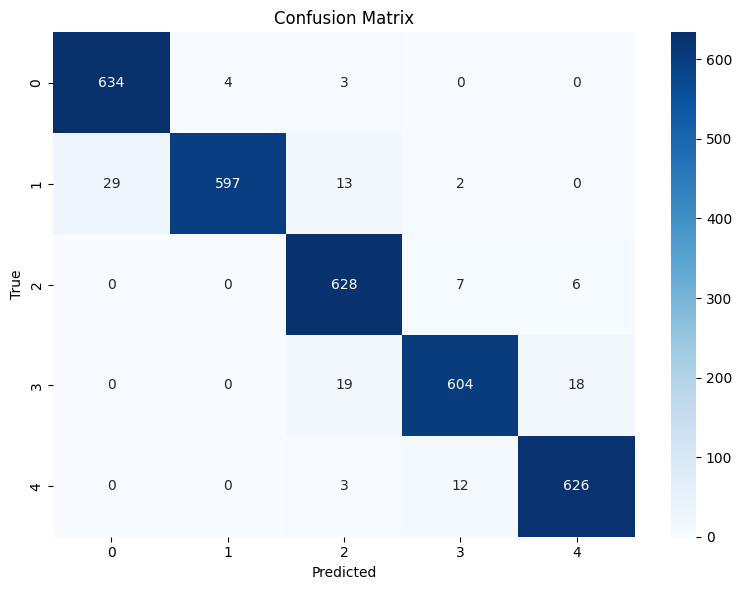


Evaluating final model on test set...
Classification Report:
              precision    recall  f1-score   support

     Class 0     0.9128    0.9691    0.9401       162
     Class 1     0.9789    0.8580    0.9145       162
     Class 2     0.9240    0.9753    0.9489       162
     Class 3     0.9689    0.9630    0.9659       162
     Class 4     0.9634    0.9753    0.9693       162

    accuracy                         0.9481       810
   macro avg     0.9496    0.9481    0.9478       810
weighted avg     0.9496    0.9481    0.9478       810



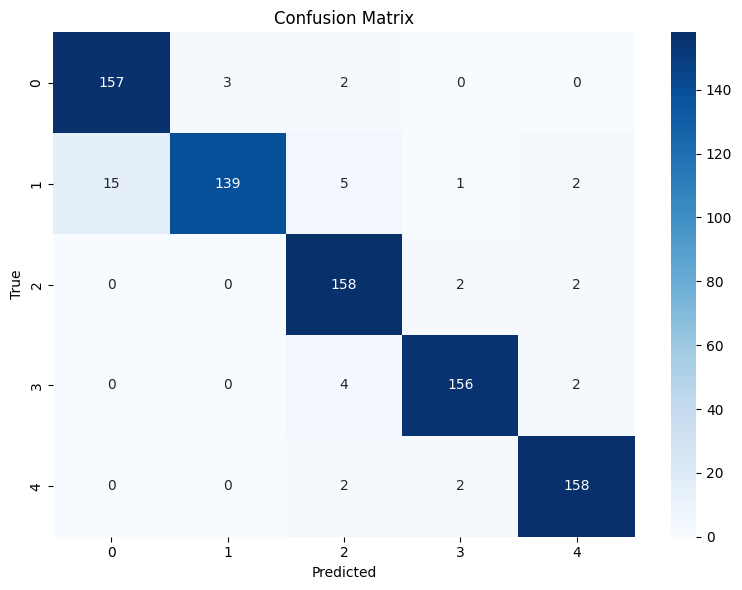

In [ ]:
#dropout_0.2
####
import argparse
from os import path
import torch
import numpy
import random
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, dataloader, device, class_names=None):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for b in range(len(dataloader)):
            batch = dataloader[b]
            inputs, targets = (t.to(device) for t in batch)
            predictions = model(inputs, ep=0)
            preds = torch.argmax(predictions, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    # report = classification_report(all_targets, all_preds, target_names=class_names, digits=4)
    from sklearn.utils.multiclass import unique_labels

    labels = sorted(list(unique_labels(all_targets, all_preds)))
    target_names = [f"Class {i}" for i in labels]

    report = classification_report(all_targets, all_preds, target_names=target_names, digits=4)

    print("Classification Report:")
    print(report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()


def initialize(seed: int):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def basic_smooth_crossentropy(pred, target, smoothing=0.1):
    n_class = pred.size(1)
    true_dist = torch.full_like(pred, fill_value=smoothing / (n_class - 1)).to(pred.device)
    true_dist.scatter_(dim=1, index=target.unsqueeze(1), value=1.0 - smoothing)
    log_prob = F.log_softmax(pred, dim=1)

    return torch.mean(torch.sum(-true_dist * log_prob, dim=1))


def main(args):
    device = torch.device(args.device)
    initialize(seed=42)

    print("Dataset: %s" % args.dataset_name)
    dataset_path = path.join(*['/mit-bih-datasets/MIT_BIH', args.dataset_name])
    train_file_path = path.join(dataset_path, '{}_train.csv'.format(args.dataset_name))
    test_file_path = path.join(dataset_path, '{}_test.csv'.format(args.dataset_name))

    training_set_loader = UnivariateDataset(train_file_path, batch_size=args.batch_size, is_train=1)
    testing_set_loader = UnivariateDataset(test_file_path, batch_size=args.batch_size, is_train=0)

    len_of_ts = len(training_set_loader.data[0])
    num_classes = len(numpy.unique(training_set_loader.labels))
    # Change batch_size based on number of instances
    if training_set_loader.number_of_instance < 100:
        args.batch_size = 16
    elif training_set_loader.number_of_instance < 200:
        args.batch_size = 32
    elif training_set_loader.number_of_instance < 400:
        args.batch_size = 64
    elif training_set_loader.number_of_instance < 800:
        args.batch_size = 128
    else:
        args.batch_size = 256

    training_set_loader.update_batch_size(args.batch_size)
    testing_set_loader.update_batch_size(2048)

    import pickle

    with open("/kaggle/input/parame/shapelets_info_ws10_n0.2_641.pkl", "rb") as f:
          shapelets_info = pickle.load(f)
    print("So luong shapelet la: ",len(shapelets_info))
    shapelets = []
    for si in shapelets_info:
        sc = training_set_loader.data[int(si[0]),int(si[1]):int(si[2])]
        shapelets.append(sc)

    model = LearningPShapeletsModel(shapelets_info=shapelets_info, shapelets=shapelets,
                                    len_ts=len_of_ts, num_classes=num_classes, sge=args.sge,
                                    window_size=args.window_size, bounding_norm=args.bounding_norm)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(),lr=args.lr, weight_decay=args.weight_decay)
    gamma = (1e-4 / args.lr) ** (1 / args.epochs)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    log = Log(log_each=3)
    for epoch in range(args.epochs+1):
        model.train()
        log.train(len_dataset=len(training_set_loader))

        for b in range(len(training_set_loader)):
            batch = training_set_loader[b]
            inputs, targets = (b.to(device) for b in batch)

            optimizer.zero_grad()
            predictions = model(inputs,epoch)
            loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
            loss.mean().backward()
            optimizer.step()

            with torch.no_grad():
                correct = torch.argmax(predictions.data, 1) == targets
                log(model, loss.cpu(), correct.cpu(), optimizer.param_groups[0]['lr'])

        if epoch % args.sep == 0:
            model.eval()
            log.eval(len_dataset=len(testing_set_loader))

            with torch.no_grad():
                for b in range(len(testing_set_loader)):
                    batch = testing_set_loader[b]
                    inputs, targets = (b.to(device) for b in batch)
                    predictions = model(inputs,epoch)

                    loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
                    correct = torch.argmax(predictions, 1) == targets
                    log(model, loss.cpu(), correct.cpu())
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}: learning rate = {current_lr:.6f}")


    log.flush()
    print("\nEvaluating final model on train set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, training_set_loader, device, class_names)

    print("\nEvaluating final model on test set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, testing_set_loader, device, class_names)


if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    # Optimizer parameters.
    parser.add_argument('--momentum', type=float, default=0.9, metavar='M',
                        help='SGD momentum (default: 0.9)')
    parser.add_argument('--weight-decay', type=float, default=1e-5,
                        help='weight decay (default: 0.05)')
    parser.add_argument('--lr', type=float, default=1e-2, metavar='LR',
                        help='learning rate (default: 5e-4)')

    # General parametersƯ
    parser.add_argument("--dataset_name", default="Arrhythmia", type=str, help="dataset name")
    parser.add_argument("--num_shapelet", default=0.2, type=float, help="number of shapelets")
    parser.add_argument("--window_size", default=10, type=float, help="window size")
    parser.add_argument("--num_pip", default=0.3, type=float, help="number of pips")
    parser.add_argument("--sge", default=1, type=int, help="stop-gradient epochs")
    parser.add_argument("--processes", default=10, type=int, help="number of processes for extracting shapelets")
    parser.add_argument("--bounding_norm", default=100, type=int, help="Fixed at 100")
    parser.add_argument("--max_acc", default=0.0, type=float, help="Fixed at 0")

    parser.add_argument("--batch_size", default=8, type=int, help="Batch size used in the training and validation loop.")
    parser.add_argument("--epochs", default=5000, type=int, help="Total number of epochs.")
    parser.add_argument("--threads", default=1, type=int, help="Number of CPU threads for dataloaders.")
    parser.add_argument('--smoothing', type=float, default=0.1, help='Label smoothing (default: 0.1)')

    parser.add_argument('--device', type=str, default="cuda:0", help='Device for training model')
    parser.add_argument("--sep", default=1, type=int, help="Number of CPU threads for dataloaders.")

    args = parser.parse_args(args=[])
    print(args)
    main(args)

Namespace(momentum=0.9, weight_decay=1e-05, lr=0.01, dataset_name='ECGFiveDays', num_shapelet=0.2, window_size=10, num_pip=0.3, sge=1, processes=10, bounding_norm=100, max_acc=0.0, batch_size=8, epochs=1000, threads=1, smoothing=0.1, device='cuda:0', sep=1)
Dataset: ECGFiveDays
So luong shapelet la:  35
┏━━━━━━━━━━━━━━┳━━━━━━━╸T╺╸R╺╸A╺╸I╺╸N╺━━━━━━━┳━━━━━━━╸S╺╸T╺╸A╺╸T╺╸S╺━━━━━━━┳━━━━━━━╸V╺╸A╺╸L╺╸I╺╸D╺━━━━━━━┓
┃              ┃              ╷              ┃              ╷              ┃              ╷              ┃
┃       epoch  ┃        loss  │    accuracy  ┃        l.r.  │     elapsed  ┃        loss  │    accuracy  ┃
┠──────────────╂──────────────┼──────────────╂──────────────┼──────────────╂──────────────┼──────────────┨
┃           0  ┃      0.0090  │      0.00 %  ┃   1.000e-02  │   00:04 min  ┠┈███████████████████████████┈┨Epoch 0: learning rate = 0.009954
      0.0021  │     20.00 %  ┃
┃           1  ┃      0.0066  │     28.19 %  ┃   9.954e-03  │   00:03 min  ┠┈███████████████████

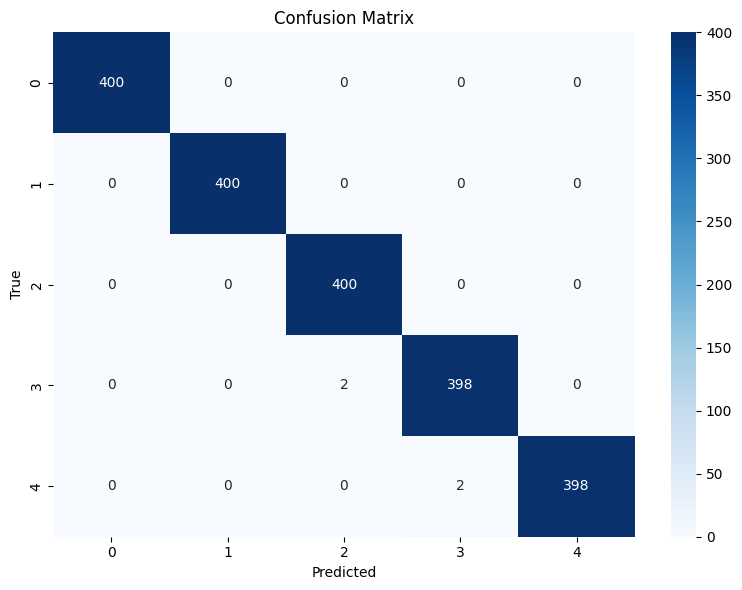


Evaluating final model on test set...
Classification Report:
              precision    recall  f1-score   support

     Class 0     0.9581    0.9877    0.9726       162
     Class 1     0.9496    0.8148    0.8771       162
     Class 2     0.8212    0.9074    0.8622       162
     Class 3     0.9107    0.9444    0.9273       162
     Class 4     1.0000    0.9691    0.9843       162

    accuracy                         0.9247       810
   macro avg     0.9279    0.9247    0.9247       810
weighted avg     0.9279    0.9247    0.9247       810



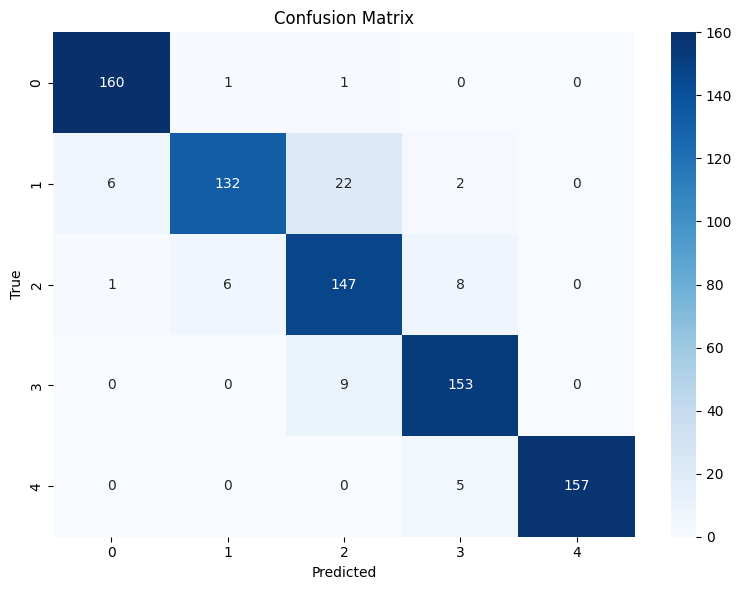

In [ ]:
#dropout_0.2
####
import argparse
from os import path
import torch
import numpy
import random
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, dataloader, device, class_names=None):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for b in range(len(dataloader)):
            batch = dataloader[b]
            inputs, targets = (t.to(device) for t in batch)
            predictions = model(inputs, ep=0)
            preds = torch.argmax(predictions, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    # report = classification_report(all_targets, all_preds, target_names=class_names, digits=4)
    from sklearn.utils.multiclass import unique_labels

    labels = sorted(list(unique_labels(all_targets, all_preds)))
    target_names = [f"Class {i}" for i in labels]

    report = classification_report(all_targets, all_preds, target_names=target_names, digits=4)

    print("Classification Report:")
    print(report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()


def initialize(seed: int):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def basic_smooth_crossentropy(pred, target, smoothing=0.1):
    n_class = pred.size(1)
    true_dist = torch.full_like(pred, fill_value=smoothing / (n_class - 1)).to(pred.device)
    true_dist.scatter_(dim=1, index=target.unsqueeze(1), value=1.0 - smoothing)
    log_prob = F.log_softmax(pred, dim=1)

    return torch.mean(torch.sum(-true_dist * log_prob, dim=1))


def main(args):
    device = torch.device(args.device)
    initialize(seed=42)

    print("Dataset: %s" % args.dataset_name)
    dataset_path = path.join(*['/mit-bih-datasets/MIT_BIH', args.dataset_name])
    train_file_path = path.join(dataset_path, '{}_train.csv'.format(args.dataset_name))
    test_file_path = path.join(dataset_path, '{}_test.csv'.format(args.dataset_name))

    training_set_loader = UnivariateDataset(train_file_path, batch_size=args.batch_size, is_train=1)
    testing_set_loader = UnivariateDataset(test_file_path, batch_size=args.batch_size, is_train=0)

    len_of_ts = len(training_set_loader.data[0])
    num_classes = len(numpy.unique(training_set_loader.labels))
    # Change batch_size based on number of instances
    if training_set_loader.number_of_instance < 100:
        args.batch_size = 16
    elif training_set_loader.number_of_instance < 200:
        args.batch_size = 32
    elif training_set_loader.number_of_instance < 400:
        args.batch_size = 64
    elif training_set_loader.number_of_instance < 800:
        args.batch_size = 128
    else:
        args.batch_size = 256

    training_set_loader.update_batch_size(args.batch_size)
    testing_set_loader.update_batch_size(2048)

    import pickle

    with open("/kaggle/input/parame/shapelets_info_ws10_n0.2_400.pkl", "rb") as f:
          shapelets_info = pickle.load(f)
    print("So luong shapelet la: ",len(shapelets_info))
    shapelets = []
    for si in shapelets_info:
        sc = training_set_loader.data[int(si[0]),int(si[1]):int(si[2])]
        shapelets.append(sc)

    model = LearningPShapeletsModel(shapelets_info=shapelets_info, shapelets=shapelets,
                                    len_ts=len_of_ts, num_classes=num_classes, sge=args.sge,
                                    window_size=args.window_size, bounding_norm=args.bounding_norm)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(),lr=args.lr, weight_decay=args.weight_decay)
    gamma = (1e-4 / args.lr) ** (1 / args.epochs)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    log = Log(log_each=3)
    for epoch in range(args.epochs+1):
        model.train()
        log.train(len_dataset=len(training_set_loader))

        for b in range(len(training_set_loader)):
            batch = training_set_loader[b]
            inputs, targets = (b.to(device) for b in batch)

            optimizer.zero_grad()
            predictions = model(inputs,epoch)
            loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
            loss.mean().backward()
            optimizer.step()

            with torch.no_grad():
                correct = torch.argmax(predictions.data, 1) == targets
                log(model, loss.cpu(), correct.cpu(), optimizer.param_groups[0]['lr'])

        if epoch % args.sep == 0:
            model.eval()
            log.eval(len_dataset=len(testing_set_loader))

            with torch.no_grad():
                for b in range(len(testing_set_loader)):
                    batch = testing_set_loader[b]
                    inputs, targets = (b.to(device) for b in batch)
                    predictions = model(inputs,epoch)

                    loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
                    correct = torch.argmax(predictions, 1) == targets
                    log(model, loss.cpu(), correct.cpu())
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}: learning rate = {current_lr:.6f}")


    log.flush()
    print("\nEvaluating final model on train set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, training_set_loader, device, class_names)

    print("\nEvaluating final model on test set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, testing_set_loader, device, class_names)


if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    # Optimizer parameters.
    parser.add_argument('--momentum', type=float, default=0.9, metavar='M',
                        help='SGD momentum (default: 0.9)')
    parser.add_argument('--weight-decay', type=float, default=1e-5,
                        help='weight decay (default: 0.05)')
    parser.add_argument('--lr', type=float, default=1e-2, metavar='LR',
                        help='learning rate (default: 5e-4)')

    # General parametersƯ
    parser.add_argument("--dataset_name", default="Arrhythmia", type=str, help="dataset name")
    parser.add_argument("--num_shapelet", default=0.2, type=float, help="number of shapelets")
    parser.add_argument("--window_size", default=10, type=float, help="window size")
    parser.add_argument("--num_pip", default=0.3, type=float, help="number of pips")
    parser.add_argument("--sge", default=1, type=int, help="stop-gradient epochs")
    parser.add_argument("--processes", default=10, type=int, help="number of processes for extracting shapelets")
    parser.add_argument("--bounding_norm", default=100, type=int, help="Fixed at 100")
    parser.add_argument("--max_acc", default=0.0, type=float, help="Fixed at 0")

    parser.add_argument("--batch_size", default=8, type=int, help="Batch size used in the training and validation loop.")
    parser.add_argument("--epochs", default=1000, type=int, help="Total number of epochs.")
    parser.add_argument("--threads", default=1, type=int, help="Number of CPU threads for dataloaders.")
    parser.add_argument('--smoothing', type=float, default=0.1, help='Label smoothing (default: 0.1)')

    parser.add_argument('--device', type=str, default="cuda:0", help='Device for training model')
    parser.add_argument("--sep", default=1, type=int, help="Number of CPU threads for dataloaders.")

    args = parser.parse_args(args=[])
    print(args)
    main(args)

Namespace(momentum=0.9, weight_decay=1e-05, lr=0.01, dataset_name='Arrhythmia', num_shapelet=0.2, window_size=10, num_pip=0.3, sge=1, processes=10, bounding_norm=100, max_acc=0.0, batch_size=8, epochs=5000, threads=1, smoothing=0.1, device='cuda:0', sep=1)
Dataset: Arrhythmia
So luong shapelet la:  35
┏━━━━━━━━━━━━━━┳━━━━━━━╸T╺╸R╺╸A╺╸I╺╸N╺━━━━━━━┳━━━━━━━╸S╺╸T╺╸A╺╸T╺╸S╺━━━━━━━┳━━━━━━━╸V╺╸A╺╸L╺╸I╺╸D╺━━━━━━━┓
┃              ┃              ╷              ┃              ╷              ┃              ╷              ┃
┃       epoch  ┃        loss  │    accuracy  ┃        l.r.  │     elapsed  ┃        loss  │    accuracy  ┃
┠──────────────╂──────────────┼──────────────╂──────────────┼──────────────╂──────────────┼──────────────┨
┃           0  ┃      0.0090  │      0.00 %  ┃   1.000e-02  │   00:01 min  ┠┈███████████████████████████┈┨Epoch 0: learning rate = 0.009991
      0.0021  │     20.00 %  ┃
┃           1  ┃      0.0066  │     28.47 %  ┃   9.991e-03  │   00:00 min  ┠┈█████████████████████

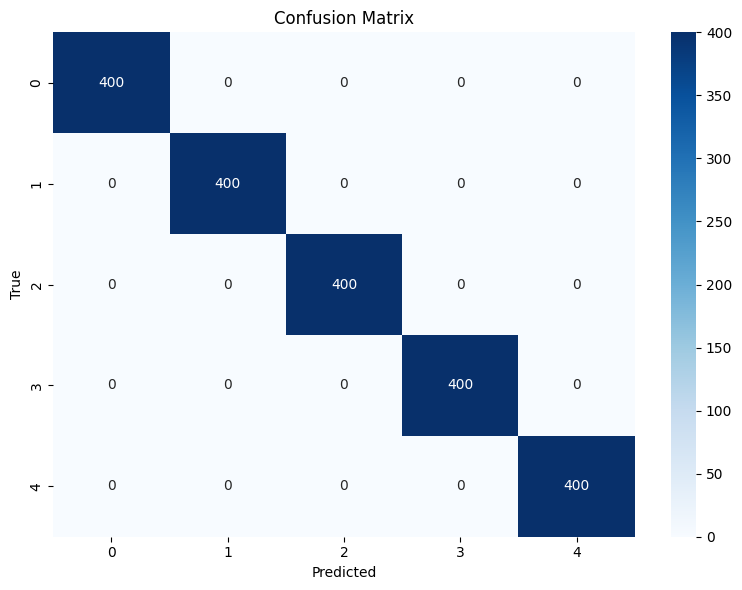


Evaluating final model on test set...
Classification Report:
              precision    recall  f1-score   support

     Class 0     0.7706    0.8086    0.7892       162
     Class 1     0.8207    0.7346    0.7752       162
     Class 2     0.9355    0.8951    0.9148       162
     Class 3     0.9000    0.9444    0.9217       162
     Class 4     0.9471    0.9938    0.9699       162

    accuracy                         0.8753       810
   macro avg     0.8748    0.8753    0.8742       810
weighted avg     0.8748    0.8753    0.8742       810



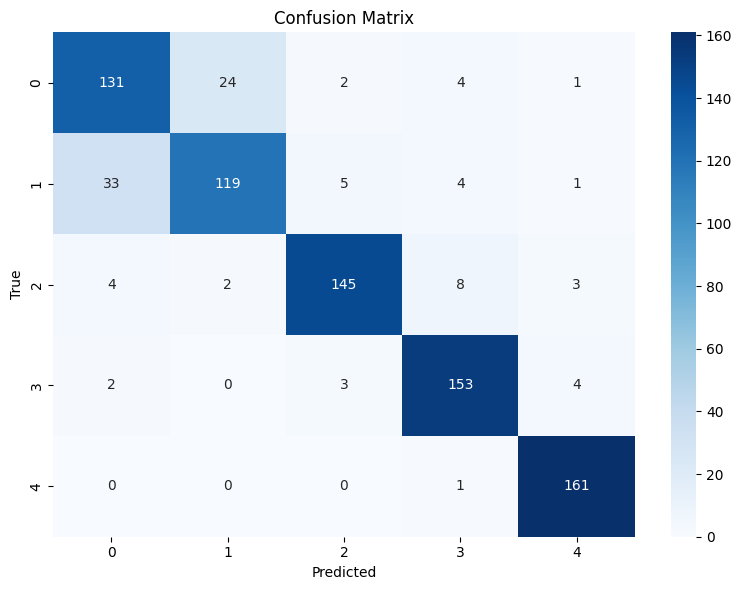

In [ ]:
#dropout_0.2
####
import argparse
from os import path
import torch
import numpy
import random
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, dataloader, device, class_names=None):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for b in range(len(dataloader)):
            batch = dataloader[b]
            inputs, targets = (t.to(device) for t in batch)
            predictions = model(inputs, ep=0)
            preds = torch.argmax(predictions, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    # report = classification_report(all_targets, all_preds, target_names=class_names, digits=4)
    from sklearn.utils.multiclass import unique_labels

    labels = sorted(list(unique_labels(all_targets, all_preds)))
    target_names = [f"Class {i}" for i in labels]

    report = classification_report(all_targets, all_preds, target_names=target_names, digits=4)

    print("Classification Report:")
    print(report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()


def initialize(seed: int):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def basic_smooth_crossentropy(pred, target, smoothing=0.1):
    n_class = pred.size(1)
    true_dist = torch.full_like(pred, fill_value=smoothing / (n_class - 1)).to(pred.device)
    true_dist.scatter_(dim=1, index=target.unsqueeze(1), value=1.0 - smoothing)
    log_prob = F.log_softmax(pred, dim=1)

    return torch.mean(torch.sum(-true_dist * log_prob, dim=1))


def main(args):
    device = torch.device(args.device)
    initialize(seed=42)

    print("Dataset: %s" % args.dataset_name)
    dataset_path = path.join(*['/kaggle/input/mit-bih-datasets/MIT_BIH', args.dataset_name])
    train_file_path = path.join(dataset_path, '{}_train.csv'.format(args.dataset_name))
    test_file_path = path.join(dataset_path, '{}_test.csv'.format(args.dataset_name))

    training_set_loader = UnivariateDataset(train_file_path, batch_size=args.batch_size, is_train=1)
    testing_set_loader = UnivariateDataset(test_file_path, batch_size=args.batch_size, is_train=0)

    len_of_ts = len(training_set_loader.data[0])
    num_classes = len(numpy.unique(training_set_loader.labels))
    # Change batch_size based on number of instances
    if training_set_loader.number_of_instance < 100:
        args.batch_size = 16
    elif training_set_loader.number_of_instance < 200:
        args.batch_size = 32
    elif training_set_loader.number_of_instance < 400:
        args.batch_size = 64
    elif training_set_loader.number_of_instance < 800:
        args.batch_size = 128
    else:
        args.batch_size = 256

    training_set_loader.update_batch_size(args.batch_size)
    testing_set_loader.update_batch_size(2048)

    # shapelet_discovery = ShapeletDiscover(window_size=args.window_size, num_pip=args.num_pip, processes=args.processes)
    # print("Extracting shapelet candidate!")
    # shapelet_discovery.extract_candidate(train_data=training_set_loader.data)
    # print("Shapelet discovery for window_size = %s" % args.window_size)
    # shapelet_discovery.discovery(train_data=training_set_loader.data, train_labels=training_set_loader.labels)
    # shapelets_info = shapelet_discovery.get_shapelet_info(number_of_shapelet=args.num_shapelet)

    # # Save to pickle
    import pickle
    # with open(f"shapelets_info_ws{args.window_size}_n{args.num_shapelet}_641.pkl", "wb") as f:
    #     pickle.dump(shapelets_info, f)
    with open("shapelets_info_ws10_n0.2_400.pkl", "rb") as f:
          shapelets_info = pickle.load(f)
    print("So luong shapelet la: ",len(shapelets_info))
    shapelets = []
    for si in shapelets_info:
        sc = training_set_loader.data[int(si[0]),int(si[1]):int(si[2])]
        shapelets.append(sc)

    model = LearningPShapeletsModel(shapelets_info=shapelets_info, shapelets=shapelets,
                                    len_ts=len_of_ts, num_classes=num_classes, sge=args.sge,
                                    window_size=args.window_size, bounding_norm=args.bounding_norm)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(),lr=args.lr, weight_decay=args.weight_decay)
    gamma = (1e-4 / args.lr) ** (1 / args.epochs)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    log = Log(log_each=3)
    for epoch in range(args.epochs+1):
        model.train()
        log.train(len_dataset=len(training_set_loader))

        for b in range(len(training_set_loader)):
            batch = training_set_loader[b]
            inputs, targets = (b.to(device) for b in batch)

            optimizer.zero_grad()
            predictions = model(inputs,epoch)
            loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
            loss.mean().backward()
            optimizer.step()

            with torch.no_grad():
                correct = torch.argmax(predictions.data, 1) == targets
                log(model, loss.cpu(), correct.cpu(), optimizer.param_groups[0]['lr'])

        if epoch % args.sep == 0:
            model.eval()
            log.eval(len_dataset=len(testing_set_loader))

            with torch.no_grad():
                for b in range(len(testing_set_loader)):
                    batch = testing_set_loader[b]
                    inputs, targets = (b.to(device) for b in batch)
                    predictions = model(inputs,epoch)

                    loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
                    correct = torch.argmax(predictions, 1) == targets
                    log(model, loss.cpu(), correct.cpu())
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}: learning rate = {current_lr:.6f}")


    log.flush()
    print("\nEvaluating final model on train set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, training_set_loader, device, class_names)

    print("\nEvaluating final model on test set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, testing_set_loader, device, class_names)


if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    # Optimizer parameters.
    parser.add_argument('--momentum', type=float, default=0.9, metavar='M',
                        help='SGD momentum (default: 0.9)')
    parser.add_argument('--weight-decay', type=float, default=1e-5,
                        help='weight decay (default: 0.05)')
    parser.add_argument('--lr', type=float, default=1e-2, metavar='LR',
                        help='learning rate (default: 5e-4)')

    # General parametersƯ
    parser.add_argument("--dataset_name", default="Arrhythmia", type=str, help="dataset name")
    parser.add_argument("--num_shapelet", default=0.2, type=float, help="number of shapelets")
    parser.add_argument("--window_size", default=10, type=float, help="window size")
    parser.add_argument("--num_pip", default=0.3, type=float, help="number of pips")
    parser.add_argument("--sge", default=1, type=int, help="stop-gradient epochs")
    parser.add_argument("--processes", default=10, type=int, help="number of processes for extracting shapelets")
    parser.add_argument("--bounding_norm", default=100, type=int, help="Fixed at 100")
    parser.add_argument("--max_acc", default=0.0, type=float, help="Fixed at 0")

    parser.add_argument("--batch_size", default=8, type=int, help="Batch size used in the training and validation loop.")
    parser.add_argument("--epochs", default=5000, type=int, help="Total number of epochs.")
    parser.add_argument("--threads", default=1, type=int, help="Number of CPU threads for dataloaders.")
    parser.add_argument('--smoothing', type=float, default=0.1, help='Label smoothing (default: 0.1)')

    parser.add_argument('--device', type=str, default="cuda:0", help='Device for training model')
    parser.add_argument("--sep", default=1, type=int, help="Number of CPU threads for dataloaders.")

    args = parser.parse_args(args=[])
    print(args)
    main(args)

Namespace(momentum=0.9, weight_decay=1e-05, lr=0.01, dataset_name='ECGFiveDays', num_shapelet=0.2, window_size=10, num_pip=0.3, sge=1, processes=10, bounding_norm=100, max_acc=0.0, batch_size=8, epochs=1000, threads=1, smoothing=0.1, device='cuda:0', sep=1)
Dataset: ECGFiveDays
So luong shapelet la:  35
┏━━━━━━━━━━━━━━┳━━━━━━━╸T╺╸R╺╸A╺╸I╺╸N╺━━━━━━━┳━━━━━━━╸S╺╸T╺╸A╺╸T╺╸S╺━━━━━━━┳━━━━━━━╸V╺╸A╺╸L╺╸I╺╸D╺━━━━━━━┓
┃              ┃              ╷              ┃              ╷              ┃              ╷              ┃
┃       epoch  ┃        loss  │    accuracy  ┃        l.r.  │     elapsed  ┃        loss  │    accuracy  ┃
┠──────────────╂──────────────┼──────────────╂──────────────┼──────────────╂──────────────┼──────────────┨
┃           0  ┃      0.0099  │     10.16 %  ┃   1.000e-02  │   00:00 min  ┠┈█████████████▒┈┈┈┈┈┈┈┈┈┈┈┈┈┈┨Epoch 0: learning rate = 0.009954
      0.0020  │     20.00 %  ┃
┃           1  ┃      0.0059  │     38.28 %  ┃   9.954e-03  │   00:00 min  ┠┈█████████████▒┈┈┈┈┈

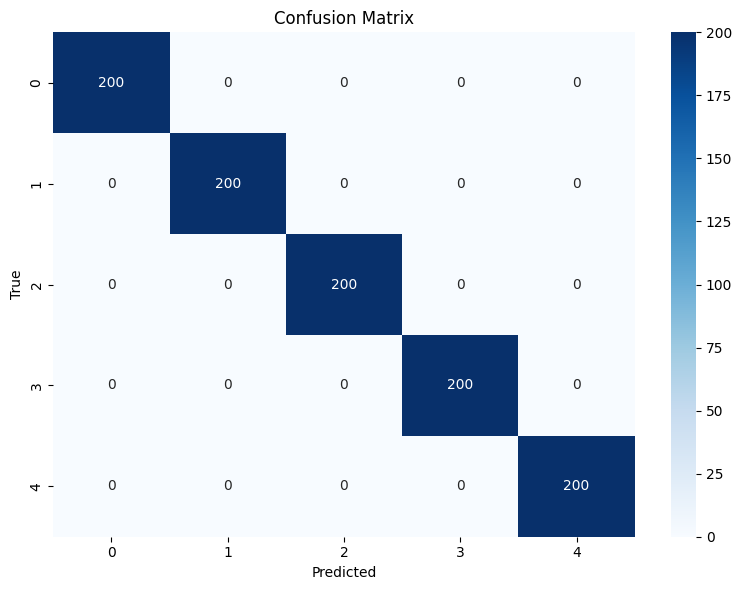


Evaluating final model on test set...
Classification Report:
              precision    recall  f1-score   support

     Class 0     0.7674    0.8148    0.7904       162
     Class 1     0.8298    0.7222    0.7723       162
     Class 2     0.8655    0.9136    0.8889       162
     Class 3     0.9515    0.9691    0.9602       162
     Class 4     0.9876    0.9815    0.9845       162

    accuracy                         0.8802       810
   macro avg     0.8804    0.8802    0.8793       810
weighted avg     0.8804    0.8802    0.8793       810



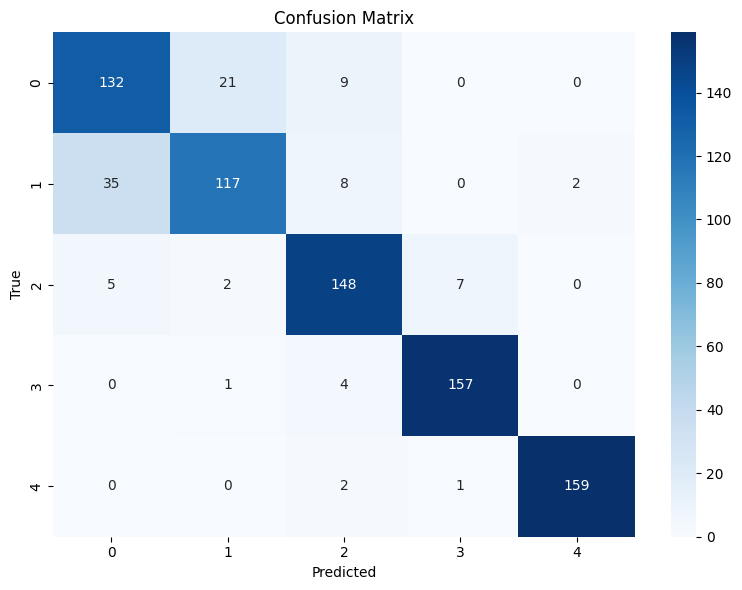

In [ ]:
#dropout_0.2
####
import argparse
from os import path
import torch
import numpy
import random
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, dataloader, device, class_names=None):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for b in range(len(dataloader)):
            batch = dataloader[b]
            inputs, targets = (t.to(device) for t in batch)
            predictions = model(inputs, ep=0)
            preds = torch.argmax(predictions, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    # report = classification_report(all_targets, all_preds, target_names=class_names, digits=4)
    from sklearn.utils.multiclass import unique_labels

    labels = sorted(list(unique_labels(all_targets, all_preds)))
    target_names = [f"Class {i}" for i in labels]

    report = classification_report(all_targets, all_preds, target_names=target_names, digits=4)

    print("Classification Report:")
    print(report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()


def initialize(seed: int):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def basic_smooth_crossentropy(pred, target, smoothing=0.1):
    n_class = pred.size(1)
    true_dist = torch.full_like(pred, fill_value=smoothing / (n_class - 1)).to(pred.device)
    true_dist.scatter_(dim=1, index=target.unsqueeze(1), value=1.0 - smoothing)
    log_prob = F.log_softmax(pred, dim=1)

    return torch.mean(torch.sum(-true_dist * log_prob, dim=1))


def main(args):
    device = torch.device(args.device)
    initialize(seed=42)

    print("Dataset: %s" % args.dataset_name)
    dataset_path = path.join(*['/mit-bih-datasets/MIT_BIH', args.dataset_name])
    train_file_path = path.join(dataset_path, '{}_train.csv'.format(args.dataset_name))
    test_file_path = path.join(dataset_path, '{}_test.csv'.format(args.dataset_name))

    training_set_loader = UnivariateDataset(train_file_path, batch_size=args.batch_size, is_train=1)
    testing_set_loader = UnivariateDataset(test_file_path, batch_size=args.batch_size, is_train=0)

    len_of_ts = len(training_set_loader.data[0])
    num_classes = len(numpy.unique(training_set_loader.labels))
    # Change batch_size based on number of instances
    if training_set_loader.number_of_instance < 100:
        args.batch_size = 16
    elif training_set_loader.number_of_instance < 200:
        args.batch_size = 32
    elif training_set_loader.number_of_instance < 400:
        args.batch_size = 64
    elif training_set_loader.number_of_instance < 800:
        args.batch_size = 128
    else:
        args.batch_size = 256

    training_set_loader.update_batch_size(args.batch_size)
    testing_set_loader.update_batch_size(2048)

    import pickle

    with open("shapelets_info_ws10_n0.2_200.pkl", "rb") as f:
          shapelets_info = pickle.load(f)
    print("So luong shapelet la: ",len(shapelets_info))
    shapelets = []
    for si in shapelets_info:
        sc = training_set_loader.data[int(si[0]),int(si[1]):int(si[2])]
        shapelets.append(sc)

    model = LearningPShapeletsModel(shapelets_info=shapelets_info, shapelets=shapelets,
                                    len_ts=len_of_ts, num_classes=num_classes, sge=args.sge,
                                    window_size=args.window_size, bounding_norm=args.bounding_norm)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(),lr=args.lr, weight_decay=args.weight_decay)
    gamma = (1e-4 / args.lr) ** (1 / args.epochs)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    log = Log(log_each=3)
    for epoch in range(args.epochs+1):
        model.train()
        log.train(len_dataset=len(training_set_loader))

        for b in range(len(training_set_loader)):
            batch = training_set_loader[b]
            inputs, targets = (b.to(device) for b in batch)

            optimizer.zero_grad()
            predictions = model(inputs,epoch)
            loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
            loss.mean().backward()
            optimizer.step()

            with torch.no_grad():
                correct = torch.argmax(predictions.data, 1) == targets
                log(model, loss.cpu(), correct.cpu(), optimizer.param_groups[0]['lr'])

        if epoch % args.sep == 0:
            model.eval()
            log.eval(len_dataset=len(testing_set_loader))

            with torch.no_grad():
                for b in range(len(testing_set_loader)):
                    batch = testing_set_loader[b]
                    inputs, targets = (b.to(device) for b in batch)
                    predictions = model(inputs,epoch)

                    loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
                    correct = torch.argmax(predictions, 1) == targets
                    log(model, loss.cpu(), correct.cpu())
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}: learning rate = {current_lr:.6f}")


    log.flush()
    print("\nEvaluating final model on train set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, training_set_loader, device, class_names)

    print("\nEvaluating final model on test set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, testing_set_loader, device, class_names)


if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    # Optimizer parameters.
    parser.add_argument('--momentum', type=float, default=0.9, metavar='M',
                        help='SGD momentum (default: 0.9)')
    parser.add_argument('--weight-decay', type=float, default=1e-5,
                        help='weight decay (default: 0.05)')
    parser.add_argument('--lr', type=float, default=1e-2, metavar='LR',
                        help='learning rate (default: 5e-4)')

    # General parametersƯ
    parser.add_argument("--dataset_name", default="Arrhythmia", type=str, help="dataset name")
    parser.add_argument("--num_shapelet", default=0.2, type=float, help="number of shapelets")
    parser.add_argument("--window_size", default=10, type=float, help="window size")
    parser.add_argument("--num_pip", default=0.3, type=float, help="number of pips")
    parser.add_argument("--sge", default=1, type=int, help="stop-gradient epochs")
    parser.add_argument("--processes", default=10, type=int, help="number of processes for extracting shapelets")
    parser.add_argument("--bounding_norm", default=100, type=int, help="Fixed at 100")
    parser.add_argument("--max_acc", default=0.0, type=float, help="Fixed at 0")

    parser.add_argument("--batch_size", default=8, type=int, help="Batch size used in the training and validation loop.")
    parser.add_argument("--epochs", default=5000, type=int, help="Total number of epochs.")
    parser.add_argument("--threads", default=1, type=int, help="Number of CPU threads for dataloaders.")
    parser.add_argument('--smoothing', type=float, default=0.1, help='Label smoothing (default: 0.1)')

    parser.add_argument('--device', type=str, default="cuda:0", help='Device for training model')
    parser.add_argument("--sep", default=1, type=int, help="Number of CPU threads for dataloaders.")

    args = parser.parse_args(args=[])
    print(args)
    main(args)

# PPSN

## 641 mẫu

Namespace(momentum=0.9, weight_decay=1e-05, lr=0.01, dataset_name='ECGFiveDays', num_shapelet=0.1, window_size=10, num_pip=0.3, sge=1, processes=10, bounding_norm=10, max_acc=0.0, batch_size=8, epochs=1000, threads=1, smoothing=0.1, device='cuda:0', sep=1)
Dataset: ECGFiveDays
So luong shapelet la:  36
┏━━━━━━━━━━━━━━┳━━━━━━━╸T╺╸R╺╸A╺╸I╺╸N╺━━━━━━━┳━━━━━━━╸S╺╸T╺╸A╺╸T╺╸S╺━━━━━━━┳━━━━━━━╸V╺╸A╺╸L╺╸I╺╸D╺━━━━━━━┓
┃              ┃              ╷              ┃              ╷              ┃              ╷              ┃
┃       epoch  ┃        loss  │    accuracy  ┃        l.r.  │     elapsed  ┃        loss  │    accuracy  ┃
┠──────────────╂──────────────┼──────────────╂──────────────┼──────────────╂──────────────┼──────────────┨
┃           0  ┃      0.0134  │      0.00 %  ┃   1.000e-02  │   00:00 min  ┠┈██████████████████████▓┈┈┈┈┈┨Epoch 0: learning rate = 0.009954
      0.0023  │     20.00 %  ┃
┃           1  ┃      0.0065  │      0.00 %  ┃   9.954e-03  │   00:00 min  ┠┈████████████████████

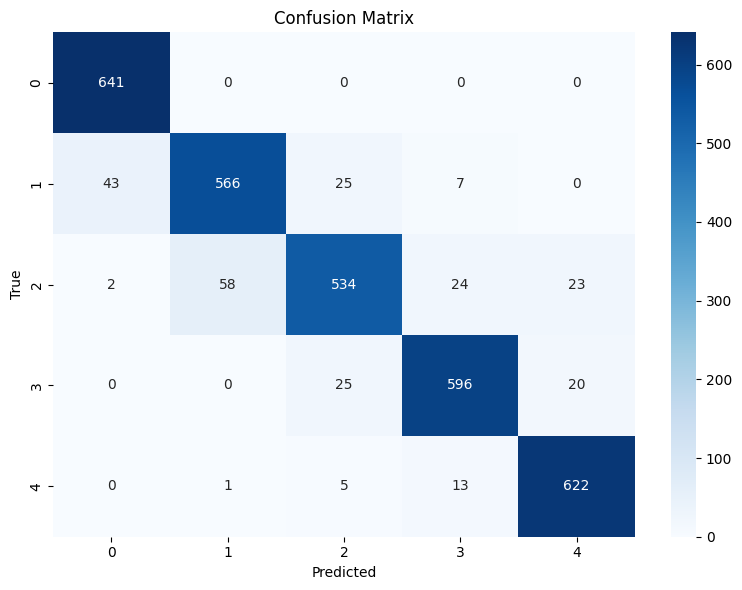


Evaluating final model on test set...
Classification Report:
              precision    recall  f1-score   support

     Class 0     0.8901    1.0000    0.9419       162
     Class 1     0.8980    0.8148    0.8544       162
     Class 2     0.9116    0.8272    0.8673       162
     Class 3     0.9286    0.9630    0.9455       162
     Class 4     0.9518    0.9753    0.9634       162

    accuracy                         0.9160       810
   macro avg     0.9160    0.9160    0.9145       810
weighted avg     0.9160    0.9160    0.9145       810



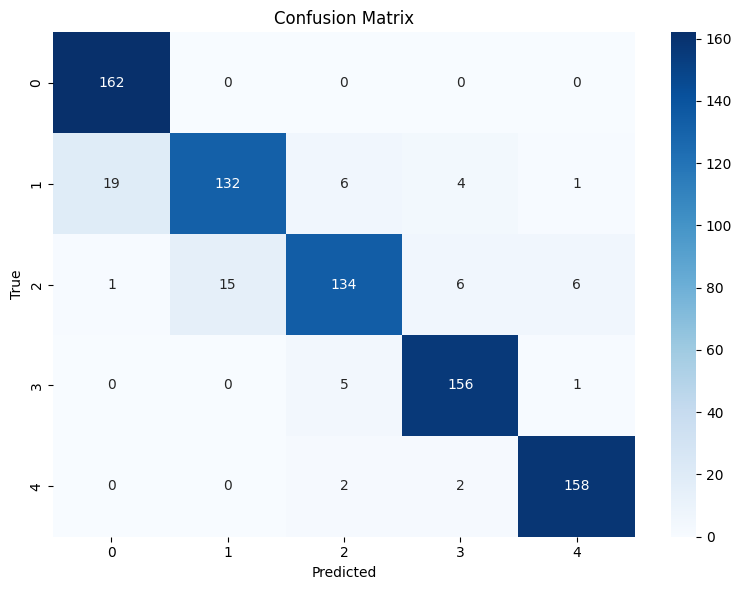

In [ ]:
#dropout_0.2
####
import argparse
from os import path
import torch
import numpy
import random
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, dataloader, device, class_names=None):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for b in range(len(dataloader)):
            batch = dataloader[b]
            inputs, targets = (t.to(device) for t in batch)
            predictions = model(inputs, ep=0)
            preds = torch.argmax(predictions, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    # report = classification_report(all_targets, all_preds, target_names=class_names, digits=4)
    from sklearn.utils.multiclass import unique_labels

    labels = sorted(list(unique_labels(all_targets, all_preds)))
    target_names = [f"Class {i}" for i in labels]

    report = classification_report(all_targets, all_preds, target_names=target_names, digits=4)

    print("Classification Report:")
    print(report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()


def initialize(seed: int):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def basic_smooth_crossentropy(pred, target, smoothing=0.1):
    n_class = pred.size(1)
    true_dist = torch.full_like(pred, fill_value=smoothing / (n_class - 1)).to(pred.device)
    true_dist.scatter_(dim=1, index=target.unsqueeze(1), value=1.0 - smoothing)
    log_prob = F.log_softmax(pred, dim=1)

    return torch.mean(torch.sum(-true_dist * log_prob, dim=1))


def main(args):
    device = torch.device(args.device)
    initialize(seed=42)

    print("Dataset: %s" % args.dataset_name)
    dataset_path = path.join(*['/mit-bih-datasets/MIT_BIH', args.dataset_name])
    train_file_path = path.join(dataset_path, '{}_train.csv'.format(args.dataset_name))
    test_file_path = path.join(dataset_path, '{}_test.csv'.format(args.dataset_name))

    training_set_loader = UnivariateDataset(train_file_path, batch_size=args.batch_size, is_train=1)
    testing_set_loader = UnivariateDataset(test_file_path, batch_size=args.batch_size, is_train=0)

    len_of_ts = len(training_set_loader.data[0])
    num_classes = len(numpy.unique(training_set_loader.labels))
    # Change batch_size based on number of instances
    if training_set_loader.number_of_instance < 100:
        args.batch_size = 16
    elif training_set_loader.number_of_instance < 200:
        args.batch_size = 32
    elif training_set_loader.number_of_instance < 400:
        args.batch_size = 64
    elif training_set_loader.number_of_instance < 800:
        args.batch_size = 128
    else:
        args.batch_size = 256

    training_set_loader.update_batch_size(args.batch_size)
    testing_set_loader.update_batch_size(2048)

    import pickle

    with open("shapelets_info_ws10_n0.2_641.pkl", "rb") as f:
          shapelets_info = pickle.load(f)
    print("So luong shapelet la: ",len(shapelets_info))
    shapelets = []
    for si in shapelets_info:
        sc = training_set_loader.data[int(si[0]),int(si[1]):int(si[2])]
        shapelets.append(sc)

    model = LearningPShapeletsModel(shapelets_info=shapelets_info, shapelets=shapelets,
                                    len_ts=len_of_ts, num_classes=num_classes, sge=args.sge,
                                    window_size=args.window_size, bounding_norm=args.bounding_norm)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(),lr=args.lr, weight_decay=args.weight_decay)
    gamma = (1e-4 / args.lr) ** (1 / args.epochs)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    log = Log(log_each=3)
    for epoch in range(args.epochs+1):
        model.train()
        log.train(len_dataset=len(training_set_loader))

        for b in range(len(training_set_loader)):
            batch = training_set_loader[b]
            inputs, targets = (b.to(device) for b in batch)

            optimizer.zero_grad()
            predictions = model(inputs,epoch)
            loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
            loss.mean().backward()
            optimizer.step()

            with torch.no_grad():
                correct = torch.argmax(predictions.data, 1) == targets
                log(model, loss.cpu(), correct.cpu(), optimizer.param_groups[0]['lr'])

        if epoch % args.sep == 0:
            model.eval()
            log.eval(len_dataset=len(testing_set_loader))

            with torch.no_grad():
                for b in range(len(testing_set_loader)):
                    batch = testing_set_loader[b]
                    inputs, targets = (b.to(device) for b in batch)
                    predictions = model(inputs,epoch)

                    loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
                    correct = torch.argmax(predictions, 1) == targets
                    log(model, loss.cpu(), correct.cpu())
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}: learning rate = {current_lr:.6f}")


    log.flush()
    print("\nEvaluating final model on train set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, training_set_loader, device, class_names)

    print("\nEvaluating final model on test set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, testing_set_loader, device, class_names)


if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    # Optimizer parameters.
    parser.add_argument('--momentum', type=float, default=0.9, metavar='M',
                        help='SGD momentum (default: 0.9)')
    parser.add_argument('--weight-decay', type=float, default=1e-5,
                        help='weight decay (default: 0.05)')
    parser.add_argument('--lr', type=float, default=1e-2, metavar='LR',
                        help='learning rate (default: 5e-4)')

    # General parametersƯ
    parser.add_argument("--dataset_name", default="Arrhythmia", type=str, help="dataset name")
    parser.add_argument("--num_shapelet", default=0.2, type=float, help="number of shapelets")
    parser.add_argument("--window_size", default=10, type=float, help="window size")
    parser.add_argument("--num_pip", default=0.3, type=float, help="number of pips")
    parser.add_argument("--sge", default=1, type=int, help="stop-gradient epochs")
    parser.add_argument("--processes", default=10, type=int, help="number of processes for extracting shapelets")
    parser.add_argument("--bounding_norm", default=100, type=int, help="Fixed at 100")
    parser.add_argument("--max_acc", default=0.0, type=float, help="Fixed at 0")

    parser.add_argument("--batch_size", default=8, type=int, help="Batch size used in the training and validation loop.")
    parser.add_argument("--epochs", default=1000, type=int, help="Total number of epochs.")
    parser.add_argument("--threads", default=1, type=int, help="Number of CPU threads for dataloaders.")
    parser.add_argument('--smoothing', type=float, default=0.1, help='Label smoothing (default: 0.1)')

    parser.add_argument('--device', type=str, default="cuda:0", help='Device for training model')
    parser.add_argument("--sep", default=1, type=int, help="Number of CPU threads for dataloaders.")

    args = parser.parse_args(args=[])
    print(args)
    main(args)

## 400 mẫu

Namespace(momentum=0.9, weight_decay=1e-05, lr=0.01, dataset_name='ECGFiveDays', num_shapelet=0.2, window_size=10, num_pip=0.3, sge=1, processes=10, bounding_norm=10, max_acc=0.0, batch_size=8, epochs=1000, threads=1, smoothing=0.1, device='cuda:0', sep=1)
Dataset: ECGFiveDays
So luong shapelet la:  36
┏━━━━━━━━━━━━━━┳━━━━━━━╸T╺╸R╺╸A╺╸I╺╸N╺━━━━━━━┳━━━━━━━╸S╺╸T╺╸A╺╸T╺╸S╺━━━━━━━┳━━━━━━━╸V╺╸A╺╸L╺╸I╺╸D╺━━━━━━━┓
┃              ┃              ╷              ┃              ╷              ┃              ╷              ┃
┃       epoch  ┃        loss  │    accuracy  ┃        l.r.  │     elapsed  ┃        loss  │    accuracy  ┃
┠──────────────╂──────────────┼──────────────╂──────────────┼──────────────╂──────────────┼──────────────┨
┃           0  ┃      0.0088  │      0.00 %  ┃   1.000e-02  │   00:00 min  ┠┈███████████████████████████┈┨Epoch 0: learning rate = 0.009954
      0.0021  │     20.12 %  ┃
┃           1  ┃      0.0079  │      0.00 %  ┃   9.954e-03  │   00:00 min  ┠┈████████████████████

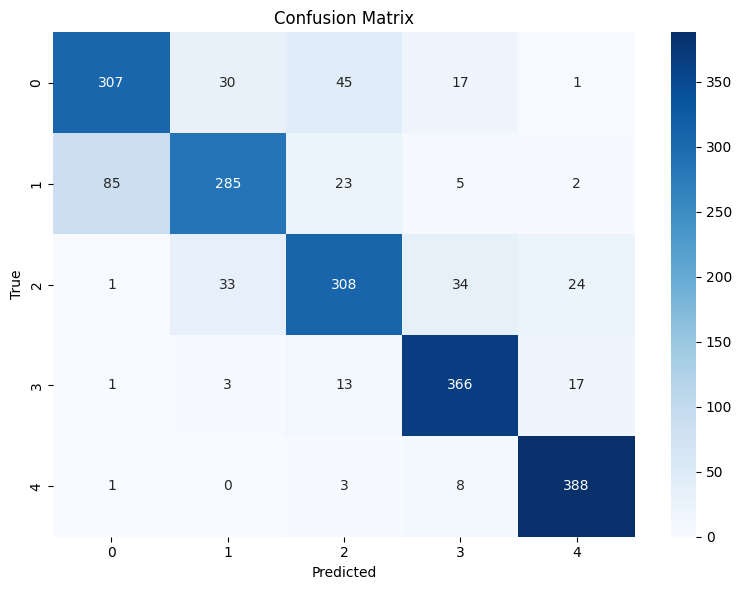


Evaluating final model on test set...
Classification Report:
              precision    recall  f1-score   support

     Class 0     0.7371    0.7963    0.7656       162
     Class 1     0.8596    0.6049    0.7101       162
     Class 2     0.7962    0.7716    0.7837       162
     Class 3     0.7812    0.9259    0.8475       162
     Class 4     0.9186    0.9753    0.9461       162

    accuracy                         0.8148       810
   macro avg     0.8186    0.8148    0.8106       810
weighted avg     0.8186    0.8148    0.8106       810



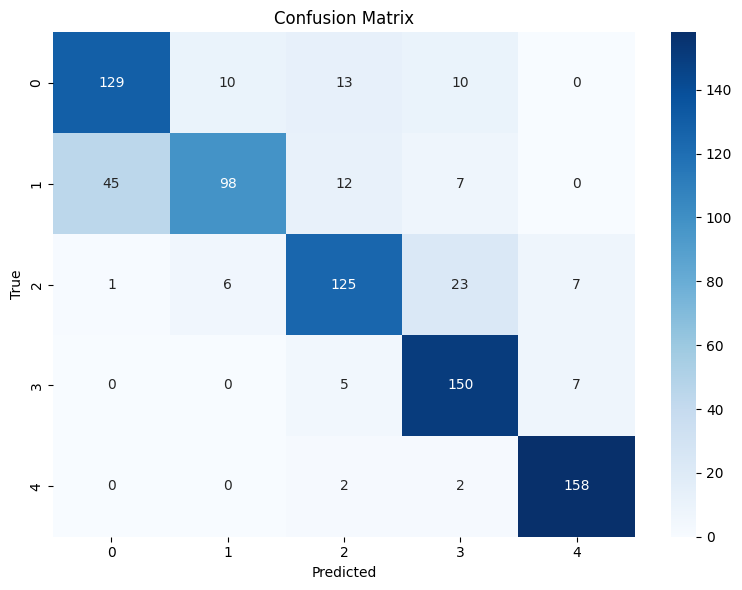

In [ ]:
#dropout_0.2
####
import argparse
from os import path
import torch
import numpy
import random
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, dataloader, device, class_names=None):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for b in range(len(dataloader)):
            batch = dataloader[b]
            inputs, targets = (t.to(device) for t in batch)
            predictions = model(inputs, ep=0)
            preds = torch.argmax(predictions, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    # report = classification_report(all_targets, all_preds, target_names=class_names, digits=4)
    from sklearn.utils.multiclass import unique_labels

    labels = sorted(list(unique_labels(all_targets, all_preds)))
    target_names = [f"Class {i}" for i in labels]

    report = classification_report(all_targets, all_preds, target_names=target_names, digits=4)

    print("Classification Report:")
    print(report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()


def initialize(seed: int):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def basic_smooth_crossentropy(pred, target, smoothing=0.1):
    n_class = pred.size(1)
    true_dist = torch.full_like(pred, fill_value=smoothing / (n_class - 1)).to(pred.device)
    true_dist.scatter_(dim=1, index=target.unsqueeze(1), value=1.0 - smoothing)
    log_prob = F.log_softmax(pred, dim=1)

    return torch.mean(torch.sum(-true_dist * log_prob, dim=1))


def main(args):
    device = torch.device(args.device)
    initialize(seed=42)

    print("Dataset: %s" % args.dataset_name)
    dataset_path = path.join(*['/mit-bih-datasets/MIT_BIH', args.dataset_name])
    train_file_path = path.join(dataset_path, '{}_train.csv'.format(args.dataset_name))
    test_file_path = path.join(dataset_path, '{}_test.csv'.format(args.dataset_name))

    training_set_loader = UnivariateDataset(train_file_path, batch_size=args.batch_size, is_train=1)
    testing_set_loader = UnivariateDataset(test_file_path, batch_size=args.batch_size, is_train=0)

    len_of_ts = len(training_set_loader.data[0])
    num_classes = len(numpy.unique(training_set_loader.labels))
    # Change batch_size based on number of instances
    if training_set_loader.number_of_instance < 100:
        args.batch_size = 16
    elif training_set_loader.number_of_instance < 200:
        args.batch_size = 32
    elif training_set_loader.number_of_instance < 400:
        args.batch_size = 64
    elif training_set_loader.number_of_instance < 800:
        args.batch_size = 128
    else:
        args.batch_size = 256

    training_set_loader.update_batch_size(args.batch_size)
    testing_set_loader.update_batch_size(2048)

    import pickle

    with open("shapelets_info_ws10_n0.2_400.pkl", "rb") as f:
          shapelets_info = pickle.load(f)
    print("So luong shapelet la: ",len(shapelets_info))
    shapelets = []
    for si in shapelets_info:
        sc = training_set_loader.data[int(si[0]),int(si[1]):int(si[2])]
        shapelets.append(sc)

    model = LearningPShapeletsModel(shapelets_info=shapelets_info, shapelets=shapelets,
                                    len_ts=len_of_ts, num_classes=num_classes, sge=args.sge,
                                    window_size=args.window_size, bounding_norm=args.bounding_norm)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(),lr=args.lr, weight_decay=args.weight_decay)
    gamma = (1e-4 / args.lr) ** (1 / args.epochs)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    log = Log(log_each=3)
    for epoch in range(args.epochs+1):
        model.train()
        log.train(len_dataset=len(training_set_loader))

        for b in range(len(training_set_loader)):
            batch = training_set_loader[b]
            inputs, targets = (b.to(device) for b in batch)

            optimizer.zero_grad()
            predictions = model(inputs,epoch)
            loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
            loss.mean().backward()
            optimizer.step()

            with torch.no_grad():
                correct = torch.argmax(predictions.data, 1) == targets
                log(model, loss.cpu(), correct.cpu(), optimizer.param_groups[0]['lr'])

        if epoch % args.sep == 0:
            model.eval()
            log.eval(len_dataset=len(testing_set_loader))

            with torch.no_grad():
                for b in range(len(testing_set_loader)):
                    batch = testing_set_loader[b]
                    inputs, targets = (b.to(device) for b in batch)
                    predictions = model(inputs,epoch)

                    loss = basic_smooth_crossentropy(predictions, targets, smoothing=args.smoothing)
                    correct = torch.argmax(predictions, 1) == targets
                    log(model, loss.cpu(), correct.cpu())
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}: learning rate = {current_lr:.6f}")


    log.flush()
    print("\nEvaluating final model on train set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, training_set_loader, device, class_names)

    print("\nEvaluating final model on test set...")
    class_names = [str(i) for i in range(num_classes)]
    evaluate_model(model, testing_set_loader, device, class_names)


if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    # Optimizer parameters.
    parser.add_argument('--momentum', type=float, default=0.9, metavar='M',
                        help='SGD momentum (default: 0.9)')
    parser.add_argument('--weight-decay', type=float, default=1e-5,
                        help='weight decay (default: 0.05)')
    parser.add_argument('--lr', type=float, default=1e-2, metavar='LR',
                        help='learning rate (default: 5e-4)')

    # General parametersƯ
    parser.add_argument("--dataset_name", default="Arrhythmia", type=str, help="dataset name")
    parser.add_argument("--num_shapelet", default=0.2, type=float, help="number of shapelets")
    parser.add_argument("--window_size", default=10, type=float, help="window size")
    parser.add_argument("--num_pip", default=0.3, type=float, help="number of pips")
    parser.add_argument("--sge", default=1, type=int, help="stop-gradient epochs")
    parser.add_argument("--processes", default=10, type=int, help="number of processes for extracting shapelets")
    parser.add_argument("--bounding_norm", default=100, type=int, help="Fixed at 100")
    parser.add_argument("--max_acc", default=0.0, type=float, help="Fixed at 0")

    parser.add_argument("--batch_size", default=8, type=int, help="Batch size used in the training and validation loop.")
    parser.add_argument("--epochs", default=1000, type=int, help="Total number of epochs.")
    parser.add_argument("--threads", default=1, type=int, help="Number of CPU threads for dataloaders.")
    parser.add_argument('--smoothing', type=float, default=0.1, help='Label smoothing (default: 0.1)')

    parser.add_argument('--device', type=str, default="cuda:0", help='Device for training model')
    parser.add_argument("--sep", default=1, type=int, help="Number of CPU threads for dataloaders.")

    args = parser.parse_args(args=[])
    print(args)
    main(args)

# CNN

In [ ]:
from tensorflow.keras import models, layers, utils

def cnn_model(feature, depth, num_classes):
    inputs = layers.Input(shape=(feature, depth))
    C   = layers.Conv1D(filters=32, kernel_size=5, strides=1)(inputs)

    C11 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
    A11 = layers.Activation("relu")(C11)
    C12 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
    S11 = layers.Add()([C12, C])
    A12 = layers.Activation("relu")(S11)
    M11 = layers.MaxPooling1D(pool_size=5, strides=2)(A12)

    C21 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
    A21 = layers.Activation("relu")(C21)
    C22 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
    S21 = layers.Add()([C22, M11])
    A22 = layers.Activation("relu")(S21)
    M21 = layers.MaxPooling1D(pool_size=5, strides=2)(A22)

    C31 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
    A31 = layers.Activation("relu")(C31)
    C32 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
    S31 = layers.Add()([C32, M21])
    A32 = layers.Activation("relu")(S31)
    M31 = layers.MaxPooling1D(pool_size=5, strides=2)(A32)

    C41 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
    A41 = layers.Activation("relu")(C41)
    C42 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
    S41 = layers.Add()([C42, M31])
    A42 = layers.Activation("relu")(S41)
    M41 = layers.MaxPooling1D(pool_size=5, strides=2)(A42)

    C51 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
    A51 = layers.Activation("relu")(C51)
    C52 = layers.Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
    S51 = layers.Add()([C52, M41])
    A52 = layers.Activation("relu")(S51)
    M51 = layers.MaxPooling1D(pool_size=5, strides=2)(A52)

    F1  = layers.Flatten()(M51)
    D1  = layers.Dense(32)(F1)
    A6  = layers.Activation("relu")(D1)
    D2  = layers.Dense(32)(A6)
    outputs = layers.Dense(num_classes, activation="softmax")(D2)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model


## Kết quả CNN

## 200 mẫu

In [ ]:
train_df = pd.read_csv("/content/data/Arrhythmia_200_train.csv", header=None)
test_df = pd.read_csv("/content/data/Arrhythmia_test.csv", header=None)
train_df = train_df.iloc[1:].reset_index(drop=True)
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

In [ ]:
X_train = np.expand_dims(X_train, 2)
X_test = np.expand_dims(X_test, 2)

y_train = utils.to_categorical(y_train,num_classes=5)
y_test  = utils.to_categorical(y_test,num_classes=5)

n_obs, feature, depth = X_train.shape
num_classes= 5



from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# checkpoint_cb = ModelCheckpoint('MyModel10m_28/4.keras', save_best_only=True)

earlystop_cb = EarlyStopping(patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-4)

In [ ]:
model_200 = cnn_model(feature=feature, depth=depth, num_classes=5)
model_200.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
batch_size = 32
num_epochs = 100
history = model_200.fit(
    X_train, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr]
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.3578 - loss: 1.5081 - val_accuracy: 0.4407 - val_loss: 1.2635 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6133 - loss: 1.0011 - val_accuracy: 0.6531 - val_loss: 0.9504 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7189 - loss: 0.7982 - val_accuracy: 0.7247 - val_loss: 0.7093 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8009 - loss: 0.5852 - val_accuracy: 0.7222 - val_loss: 0.6901 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8061 - loss: 0.5441 - val_accuracy: 0.7556 - val_loss: 0.6472 - learning_rate: 0.0010
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8269 - loss: 0.5048 - val_accuracy: 0.7617 - val_loss: 0.6419 - learning_rate: 0.0010
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8217 - loss: 0.5098 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

labels = ["Normal",
          "Artial Premature",
          "Premature ventricular contraction",
          "Fusion of ventricular and normal",
          "Fusion of paced and normal"]
# test
predY = model_200.predict(X_train)
y_pred = np.argmax(predY,axis=1)
y_actual = np.argmax(y_train,axis=1)
cm = confusion_matrix(y_actual, y_pred)
print(cm)
print(classification_report(y_actual, y_pred, target_names=labels))

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
[[183  10   2   5   0]
 [ 20 176   4   0   0]
 [  4   2 187   7   0]
 [  5   1   6 188   0]
 [ 12   0   2   0 186]]
                                   precision    recall  f1-score   support

                           Normal       0.82      0.92      0.86       200
                 Artial Premature       0.93      0.88      0.90       200
Premature ventricular contraction       0.93      0.94      0.93       200
 Fusion of ventricular and normal       0.94      0.94      0.94       200
       Fusion of paced and normal       1.00      0.93      0.96       200

                         accuracy                           0.92      1000
                        macro avg       0.92      0.92      0.92      1000
                     weighted avg       0.92      0.92      0.92      1000



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

labels = ["Normal",
          "Artial Premature",
          "Premature ventricular contraction",
          "Fusion of ventricular and normal",
          "Fusion of paced and normal"]
# test
predY = model_200.predict(X_test)
y_pred = np.argmax(predY,axis=1)
y_actual = np.argmax(y_test,axis=1)
cm = confusion_matrix(y_actual, y_pred)
print(cm)
print(classification_report(y_actual, y_pred, target_names=labels))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[130  19   3  10   0]
 [ 39 113   4   6   0]
 [ 11   5 139   7   0]
 [ 10   0   6 146   0]
 [ 11   1   5   1 144]]
                                   precision    recall  f1-score   support

                           Normal       0.65      0.80      0.72       162
                 Artial Premature       0.82      0.70      0.75       162
Premature ventricular contraction       0.89      0.86      0.87       162
 Fusion of ventricular and normal       0.86      0.90      0.88       162
       Fusion of paced and normal       1.00      0.89      0.94       162

                         accuracy                           0.83       810
                        macro avg       0.84      0.83      0.83       810
                     weighted avg       0.84      0.83      0.83       810



## 400 mẫu

In [ ]:
train_df = pd.read_csv("/content/data/Arrhythmia_400_train.csv", header=None)
test_df = pd.read_csv("/content/data/Arrhythmia_test.csv", header=None)
train_df = train_df.iloc[1:].reset_index(drop=True)
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

In [ ]:
X_train = np.expand_dims(X_train, 2)
X_test = np.expand_dims(X_test, 2)

y_train = utils.to_categorical(y_train,num_classes=5)
y_test  = utils.to_categorical(y_test,num_classes=5)

n_obs, feature, depth = X_train.shape
num_classes= 5



from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

checkpoint_cb = ModelCheckpoint('MyModel10m_28/4.keras', save_best_only=True)

earlystop_cb = EarlyStopping(patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-4)

In [ ]:
model_400 = cnn_model(feature=feature, depth=depth, num_classes=5)
model_400.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
batch_size = 128
num_epochs = 100
history = model_400.fit(
    X_train, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr]
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 239ms/step - accuracy: 0.3723 - loss: 1.5095 - val_accuracy: 0.5938 - val_loss: 1.0861 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6404 - loss: 0.9839 - val_accuracy: 0.7074 - val_loss: 0.8479 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7096 - loss: 0.7933 - val_accuracy: 0.7321 - val_loss: 0.7277 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7555 - loss: 0.6793 - val_accuracy: 0.7346 - val_loss: 0.6772 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7887 - loss: 0.6223 - val_accuracy: 0.8000 - val_loss: 0.5899 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8216 - loss: 0.5472 - val_accuracy: 0.7938 - val_loss: 0.5834 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8151 - loss: 0.5068 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

labels = ["Normal",
          "Artial Premature",
          "Premature ventricular contraction",
          "Fusion of ventricular and normal",
          "Fusion of paced and normal"]
# test
predY = model_400.predict(X_train)
y_pred = np.argmax(predY,axis=1)
y_actual = np.argmax(y_train,axis=1)
cm = confusion_matrix(y_actual, y_pred)
print(cm)
print(classification_report(y_actual, y_pred, target_names=labels))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
[[361  10   6  19   3]
 [  9 388   2   1   0]
 [  8   1 382   7   2]
 [ 14   0  15 371   0]
 [  9   0   3   1 387]]
                                   precision    recall  f1-score   support

                           Normal       0.90      0.90      0.90       399
                 Artial Premature       0.97      0.97      0.97       400
Premature ventricular contraction       0.94      0.95      0.95       400
 Fusion of ventricular and normal       0.93      0.93      0.93       400
       Fusion of paced and normal       0.99      0.97      0.98       400

                         accuracy                           0.94      1999
                        macro avg       0.95      0.94      0.95      1999
                     weighted avg       0.95      0.94      0.95      1999



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

labels = ["Normal",
          "Artial Premature",
          "Premature ventricular contraction",
          "Fusion of ventricular and normal",
          "Fusion of paced and normal"]
# test
predY = model_400.predict(X_test)
y_pred = np.argmax(predY,axis=1)
y_actual = np.argmax(y_test,axis=1)
cm = confusion_matrix(y_actual, y_pred)
print(cm)
print(classification_report(y_actual, y_pred, target_names=labels))

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
[[130  20   3   7   2]
 [ 29 126   5   2   0]
 [  8   2 144   5   3]
 [  1   2  12 147   0]
 [  6   0   5   0 151]]
                                   precision    recall  f1-score   support

                           Normal       0.75      0.80      0.77       162
                 Artial Premature       0.84      0.78      0.81       162
Premature ventricular contraction       0.85      0.89      0.87       162
 Fusion of ventricular and normal       0.91      0.91      0.91       162
       Fusion of paced and normal       0.97      0.93      0.95       162

                         accuracy                           0.86       810
                        macro avg       0.86      0.86      0.86       810
                     weighted avg       0.86      0.86      0.86       810



## 641 mẫu

In [ ]:
train_df = pd.read_csv("/content/data/Arrhythmia_641_train.csv", header=None)
test_df = pd.read_csv("/content/data/Arrhythmia_test.csv", header=None)
train_df = train_df.iloc[1:].reset_index(drop=True)
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

In [ ]:
X_train = np.expand_dims(X_train, 2)
X_test = np.expand_dims(X_test, 2)

y_train = utils.to_categorical(y_train,num_classes=5)
y_test  = utils.to_categorical(y_test,num_classes=5)

n_obs, feature, depth = X_train.shape
num_classes= 5



from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

checkpoint_cb = ModelCheckpoint('MyModel10m_28/4.keras', save_best_only=True)

earlystop_cb = EarlyStopping(patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-4)

In [ ]:
model_641 = cnn_model(feature=feature, depth=depth, num_classes=5)
model_641.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
batch_size = 256
num_epochs = 50
history = model_641.fit(
    X_train, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr]
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 286ms/step - accuracy: 0.3757 - loss: 1.5244 - val_accuracy: 0.6420 - val_loss: 1.2171 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6163 - loss: 1.1383 - val_accuracy: 0.7074 - val_loss: 0.8604 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7011 - loss: 0.8402 - val_accuracy: 0.7321 - val_loss: 0.7230 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7312 - loss: 0.6796 - val_accuracy: 0.7654 - val_loss: 0.6606 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7979 - loss: 0.6021 - val_accuracy: 0.7741 - val_loss: 0.5818 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8226 - loss: 0.5243 - val_accuracy: 0.7877 - val_loss: 0.5552 - learning_rate: 0.0010
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8208 - loss: 0.5040 - val_a

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

labels = ["Normal",
          "Artial Premature",
          "Premature ventricular contraction",
          "Fusion of ventricular and normal",
          "Fusion of paced and normal"]
# test
predY = model_641.predict(X_train)
y_pred = np.argmax(predY,axis=1)
y_actual = np.argmax(y_train,axis=1)
cm = confusion_matrix(y_actual, y_pred)
print(cm)
print(classification_report(y_actual, y_pred, target_names=labels))

101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
[[583  21  14  20   3]
 [ 67 565   6   2   1]
 [ 14   6 601  18   2]
 [ 40   2  38 561   0]
 [ 10   0   5   1 625]]
                                   precision    recall  f1-score   support

                           Normal       0.82      0.91      0.86       641
                 Artial Premature       0.95      0.88      0.91       641
Premature ventricular contraction       0.91      0.94      0.92       641
 Fusion of ventricular and normal       0.93      0.88      0.90       641
       Fusion of paced and normal       0.99      0.98      0.98       641

                         accuracy                           0.92      3205
                        macro avg       0.92      0.92      0.92      3205
                     weighted avg       0.92      0.92      0.92      3205



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

labels = ["Normal",
          "Artial Premature",
          "Premature ventricular contraction",
          "Fusion of ventricular and normal",
          "Fusion of paced and normal"]
# test
predY = model_641.predict(X_test)
y_pred = np.argmax(predY,axis=1)
y_actual = np.argmax(y_test,axis=1)
cm = confusion_matrix(y_actual, y_pred)
print(cm)
print(classification_report(y_actual, y_pred, target_names=labels))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[125  19   6  10   2]
 [ 25 126   6   5   0]
 [  4   0 149   7   2]
 [  3   0   8 151   0]
 [  5   0   4   0 153]]
                                   precision    recall  f1-score   support

                           Normal       0.77      0.77      0.77       162
                 Artial Premature       0.87      0.78      0.82       162
Premature ventricular contraction       0.86      0.92      0.89       162
 Fusion of ventricular and normal       0.87      0.93      0.90       162
       Fusion of paced and normal       0.97      0.94      0.96       162

                         accuracy                           0.87       810
                        macro avg       0.87      0.87      0.87       810
                     weighted avg       0.87      0.87      0.87       810

